<a href="https://colab.research.google.com/github/Deivs117/ProyectoSeriesTiempo/blob/main/KTALYNA_DAVID_TF_serie_tiempo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Pronóstico de Consumo Eléctrico con Deep Learning
## Dataset: Individual Household Electric Power Consumption — UCI ML Repository

---

## 0. Problemática

### Contexto
El consumo eléctrico residencial representa aproximadamente el 27% del
consumo energético total en países desarrollados. Un hogar promedio no
tiene visibilidad sobre su propio patrón de consumo — solo lo descubre
cuando llega la factura mensual. Esto impide tomar decisiones preventivas
como redistribuir el uso de electrodomésticos de alta potencia hacia
horas de tarifa baja.

### Problema
**¿Es posible anticipar el consumo eléctrico de un hogar con una hora
de anticipación, usando únicamente el historial reciente de sus propias
variables eléctricas?**

Sin un sistema de pronóstico:
- El hogar no puede optimizar su consumo en tiempo real.
- La distribuidora eléctrica no puede anticipar picos de demanda
  a nivel de usuario individual.
- No es posible detectar anomalías de consumo de forma automática
  — por ejemplo un electrodoméstico defectuoso que consume de más.

### ¿Por qué es difícil?
El consumo eléctrico es una señal compleja porque combina:
- **Ciclos regulares:** patrones diarios (mañana/noche) y semanales
  (laborable/fin de semana) que se repiten pero no son idénticos.
- **Eventos aleatorios:** encender el horno, una lavadora, el aire
  acondicionado — eventos impredecibles que generan picos abruptos.
- **Múltiples variables correlacionadas:** voltaje, potencia reactiva,
  submedidores — cada una aporta una dimensión distinta del consumo.

---

## 1. Solución propuesta

### Enfoque
Se propone un sistema de pronóstico basado en **Deep Learning sobre
series de tiempo multivariadas**, desplegado en entorno **Cloud**,
que toma las últimas 24 horas de mediciones eléctricas del hogar
y predice el consumo 1 hora hacia el futuro.

### ¿Por qué Deep Learning y no modelos clásicos?
Los modelos clásicos como ARIMA o SARIMA asumen linealidad y requieren
stationariedad estricta. El consumo eléctrico tiene:
- Patrones no lineales (picos abruptos por electrodomésticos).
- Múltiples estacionalidades superpuestas (diaria + semanal).
- Variables exógenas (voltaje, submedidores) que ARIMA no incorpora.

El Deep Learning maneja todo esto de forma nativa.

### Entorno de despliegue: Cloud
El sistema opera en Cloud porque:
- Los modelos (LSTM, Transformer) requieren más memoria de la que
  un dispositivo embebido puede ofrecer económicamente.
- El caso de uso es un **dashboard de monitoreo remoto** con alertas
  de consumo anómalo — una latencia de 500ms–2s es completamente aceptable.
- El reentrenamiento automático es trivial en Cloud: cuando el MAE en
  producción supera **1.2× el MAE de referencia**, el pipeline MLOps
  dispara un nuevo ciclo de entrenamiento.

### Formulación matemática
La serie de consumo se descompone como:

$$x_t = T_t + S_t^{(24)} + S_t^{(168)} + \varepsilon_t$$

Donde:
- $T_t$ = tendencia de largo plazo
- $S_t^{(24)}$ = componente estacional diaria (ciclo de 24h)
- $S_t^{(168)}$ = componente estacional semanal (ciclo de 168h)
- $\varepsilon_t$ = ruido aleatorio no predecible

El modelo aprende a estimar $\hat{x}_{t+1}$ dado:

$$\mathbf{X} = [x_{t-23}, x_{t-22}, \ldots, x_t] \in \mathbb{R}^{24 \times 9}$$

### Justificación de la ventana y el horizonte
- **24h de historia:** cubre exactamente $S_t^{(24)}$ — un ciclo diario
  completo. El modelo puede ubicar la predicción dentro del ciclo circadiano.
- **1h de horizonte:** operacionalmente útil para gestión energética en
  tiempo real. Horizontes mayores aumentan exponencialmente la incertidumbre
  en $\varepsilon_t$.

### Modelos comparados
Se entrenan y comparan cuatro arquitecturas para identificar cuál
captura mejor la estructura temporal del consumo:

| Modelo | Idea central |
|---|---|
| **Baseline** | Repite el último valor conocido — piso mínimo de referencia |
| **Conv1D** | Detecta patrones locales mediante filtros convolucionales |
| **LSTM** | Aprende dependencias de largo plazo mediante memoria recurrente |
| **Transformer** | Pondera cada paso de la ventana mediante atención |

---

### 3. Latencia de inferencia: documentación obligatoria para viabilidad técnica

Aunque para un horizonte de 1 hora la latencia de inferencia en milisegundos **no representa un cuello de botella operativo crítico**, su documentación explícita es **obligatoria** por las siguientes razones de ingeniería de sistemas:

1. **Ciclo de vida del modelo:** la latencia basal en producción establece la línea de referencia (*performance baseline*) para detectar degradación futura causada por **Data Drift** (cambio en la distribución de $x_t$) o **Concept Drift** (cambio en la relación $f: x_t \rightarrow y_{t+h}$). Si la latencia p99 sube un 40% en 6 meses sin cambio de hardware, es señal de que el modelo está siendo forzado a compensar errores de representación con más cómputo (p. ej., mayor profundidad de embedding).
2. **Estrategia de reentrenamiento:** para planificar el ciclo de reentrenamiento continuo (CI/CD de modelos — MLOps), se necesita comparar el tiempo de inferencia antes y después del reentrenamiento para garantizar que la nueva versión es **Pareto-dominante** (mejores métricas estadísticas AND latencia equivalente o inferior).
3. **SLA formal:** un contrato de nivel de servicio para sistemas de monitoreo energético residencial exige que el sistema emita una predicción dentro de un ventana de latencia $L_{SLA}$ acotada, siendo usual $L_{SLA} \leq 100$ ms para Edge y $\leq 50$ ms (p99) para Cloud.

Por lo tanto, se medirá y reportará explícitamente la **latencia de inferencia por muestra** para cada modelo.

---

### 4. Variable categórica `day_type`

Se deriva `day_type` desde la fecha: laborable / sábado / domingo.  
El patrón de consumo varía estructuralmente según el tipo de día — los fines de semana exhiben picos más tardíos y diferentes valles nocturnos, validado empíricamente en el EDA.

- **Variable objetivo:** `Global_active_power` (kW) — potencia activa global del hogar
- **Tipo de problema:** regresión sobre serie de tiempo multivariada
- **Features:** 9 variables (6 numéricas + 3 one-hot de tipo de día)


## 1. Librerías

In [ ]:
import os, requests, zipfile, time, warnings
warnings.filterwarnings('ignore')

#import sympy.printing
#import sympy.printing.str

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# statsmodels — pruebas formales de estacionariedad (ADF, KPSS)
from statsmodels.tsa.stattools import adfuller, kpss

plt.rcParams['figure.figsize'] = (13, 4)
sns.set_style("whitegrid")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
print(f"PyTorch:     {torch.__version__}")


Dispositivo: cuda
PyTorch:     2.10.0+cu128


## 2. Carga de datos

El dataset registra el consumo eléctrico de un hogar en Francia, minuto a minuto,
entre 2006 y 2010. Tiene 7 variables numéricas y 2 millones de filas.
Los valores faltantes están marcados con `?`.

In [ ]:
url      = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
            "00235/household_power_consumption.zip")
zip_path = "household_power_consumption.zip"
txt_path = "household_power_consumption.txt"

if not os.path.exists(txt_path):
    print("Descargando...")
    r = requests.get(url, timeout=60)
    with open(zip_path, "wb") as f:
        f.write(r.content)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(".")
    print("Descarga completa")
else:
    print("Ya existe en disco")

df_raw = pd.read_csv(txt_path, sep=";", na_values="?", low_memory=False)
print(f"Shape: {df_raw.shape}")
print(f"Columnas: {df_raw.columns.tolist()}")
df_raw.head(3)

Ya existe en disco
Shape: (2075259, 9)
Columnas: ['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0


### 2.1 Descripción de variables

| Variable | Unidad | Descripción |
|---|---|---|
| `Global_active_power` | kW | Potencia activa global consumida por el hogar — **variable objetivo** |
| `Global_reactive_power` | kVAR | Potencia reactiva global |
| `Voltage` | V | Voltaje en la red eléctrica del hogar |
| `Global_intensity` | A | Intensidad de corriente global (P = V×I) |
| `Sub_metering_1` | Wh | Submedidor 1 — cocina (lavavajillas, horno, microondas) |
| `Sub_metering_2` | Wh | Submedidor 2 — lavandería (lavadora, secadora, nevera) |
| `Sub_metering_3` | Wh | Submedidor 3 — climatización (calefacción, aire acondicionado) |

### Variable derivada
| Variable | Tipo | Descripción |
|---|---|---|
| `day_type` | Categórica | Tipo de día derivado de la fecha: **0** = laborable · **1** = sábado · **2** = domingo |

### Notas importantes
- La energía **no medida** por los submedidores corresponde a iluminación,
  televisión y otros electrodomésticos pequeños.
- La resolución original es de **1 minuto** — se submuestreará a **1 hora**.

## 3. Limpieza y preprocesamiento

## 3.1 Inspección de valores faltantes

Antes de decidir qué hacer con los nulos, hay que entender su naturaleza:
¿son errores aleatorios puntuales o bloques continuos del sensor apagado?
Eso cambia completamente la decisión de limpieza.

### 3.2 Valores faltantes
El dataset tiene aprox. 26.000 filas con valores faltantes (1.25% del total).
Estos nulos aparecen en bloques continuos, indican apagones del sensor,
no errores aleatorios. Decisión: **eliminarlos**, porque imputar bloques
de horas enteras introduciría patrones que el modelo aprendería
de forma errónea.

### 3.3 Parseo de fechas y submuestreo
Las columnas `Date` y `Time` se fusionan en un índice datetime.
Luego se submuestrea a **1 hora** usando la media, lo que reduce el dataset
de 2M a 35k filas y suaviza picos momentáneos del sensor.

### 3.3 Variable categórica: day_type
Se crea `day_type` desde la fecha: laborable (0), sábado (1), domingo (2).
El consumo en fin de semana tiene picos más tardíos y valles distintos,
esta variable le da al modelo contexto estructural que las numéricas no tienen.
Se aplica **one-hot encoding** para no introducir orden entre categorías.

### 3.4 Eliminación de Global_intensity
`Global_intensity` tiene correlación 0.99 con `Global_active_power`
porque físicamente P = V × I. Incluirla sería redundante y causaría
multicolinealidad.

                       Nulos  Porcentaje (%)
Date                       0           0.000
Time                       0           0.000
Global_active_power    25979           1.252
Global_reactive_power  25979           1.252
Voltage                25979           1.252
Global_intensity       25979           1.252
Sub_metering_1         25979           1.252
Sub_metering_2         25979           1.252
Sub_metering_3         25979           1.252

Total de bloques con nulos:       71
Bloque más largo:                 7,226 minutos (120.4 horas)
Mediana del tamaño de bloque:     1 minutos


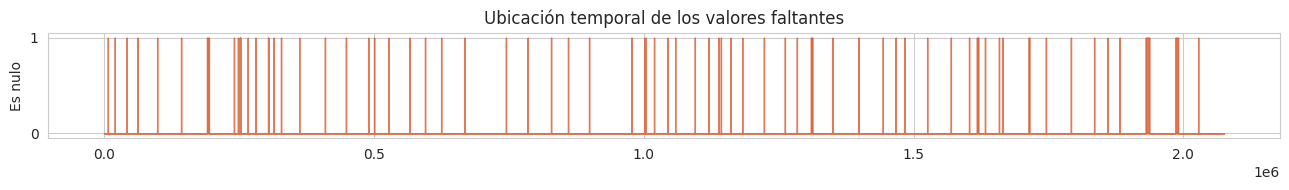

In [ ]:
nulos = df_raw.isnull().sum()
pct   = (nulos / len(df_raw) * 100).round(3)
print(pd.DataFrame({"Nulos": nulos, "Porcentaje (%)": pct}))

es_nulo = df_raw["Global_active_power"].isnull()

# Identificar bloques consecutivos de nulos
bloques = es_nulo.groupby((es_nulo != es_nulo.shift()).cumsum())
tamanos_bloques = bloques.sum()
bloques_reales  = tamanos_bloques[tamanos_bloques > 0]

print(f"\nTotal de bloques con nulos:       {len(bloques_reales)}")
print(f"Bloque más largo:                 {bloques_reales.max():,} minutos "
      f"({bloques_reales.max()/60:.1f} horas)")
print(f"Mediana del tamaño de bloque:     {bloques_reales.median():.0f} minutos")

# Visualizar dónde están los nulos en el tiempo
fig, ax = plt.subplots(figsize=(13, 2))
ax.fill_between(df_raw.index,
                es_nulo.astype(int),
                color="#D85A30", alpha=0.8)
ax.set_title("Ubicación temporal de los valores faltantes")
ax.set_ylabel("Es nulo")
ax.set_yticks([0, 1])
plt.tight_layout()
plt.show()

In [ ]:
# Parseo de fechas
df_raw["datetime"] = pd.to_datetime(
    df_raw["Date"] + " " + df_raw["Time"],
    format="%d/%m/%Y %H:%M:%S"
)
df_raw = df_raw.drop(columns=["Date", "Time"])
df_raw = df_raw.set_index("datetime").sort_index()
for col in df_raw.columns:
    df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

# Eliminar nulos
n_antes = len(df_raw)
df_raw  = df_raw.dropna()
print(f"Filas eliminadas: {n_antes - len(df_raw):,} ({(n_antes-len(df_raw))/n_antes*100:.2f}%)")

# Submuestreo a 1h
df_hourly = df_raw.resample("1h").mean().dropna()
print(f"Shape horario: {df_hourly.shape}")
print(f"Período: {df_hourly.index[0]}  →  {df_hourly.index[-1]}")

# Variable categórica
df_hourly["day_type"] = df_hourly.index.dayofweek.map(
    lambda d: 0 if d < 5 else (1 if d == 5 else 2)
)
dummies = pd.get_dummies(df_hourly["day_type"], prefix="day", dtype=float)
df_hourly = pd.concat([df_hourly, dummies], axis=1)

# Eliminar columnas redundantes
df_model = df_hourly.drop(columns=["Global_intensity", "day_type"])

print(f"\nFeatures finales: {df_model.columns.tolist()}")
print(f"Shape final: {df_model.shape}")
df_model.head(3)

Filas eliminadas: 25,979 (1.25%)
Shape horario: (34168, 7)
Período: 2006-12-16 17:00:00  →  2010-11-26 21:00:00

Features finales: ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'day_0', 'day_1', 'day_2']
Shape final: (34168, 9)


,Global_active_power,Global_reactive_power,Voltage,Sub_metering_1,Sub_metering_2,Sub_metering_3,day_0,day_1,day_2
datetime,,,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,0.0,0.527778,16.861111,0.0,1.0,0.0
2006-12-16 18:00:00,3.632200,0.080033,234.580167,0.0,6.716667,16.866667,0.0,1.0,0.0
2006-12-16 19:00:00,3.400233,0.085233,233.232500,0.0,1.433333,16.683333,0.0,1.0,0.0


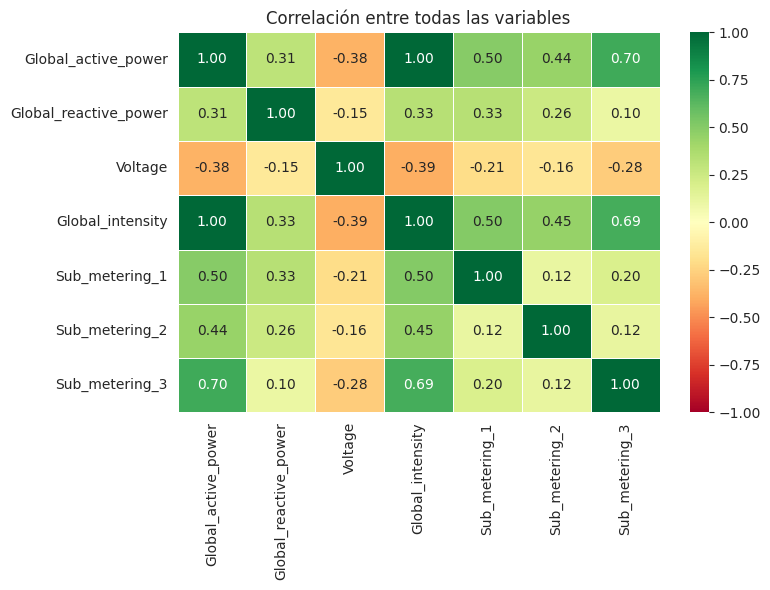

In [ ]:
# Matriz de correlación
corr_full = df_hourly[["Global_active_power",
                        "Global_reactive_power",
                        "Voltage",
                        "Global_intensity",
                        "Sub_metering_1",
                        "Sub_metering_2",
                        "Sub_metering_3"]].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_full, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-1, vmax=1, linewidths=0.4, ax=ax)
ax.set_title("Correlación entre todas las variables")
plt.tight_layout()
plt.show()

## 4. Análisis Exploratorio

Visualizamos la serie completa, el patrón horario y la diferencia entre
tipos de día para confirmar que `day_type` aporta información real.

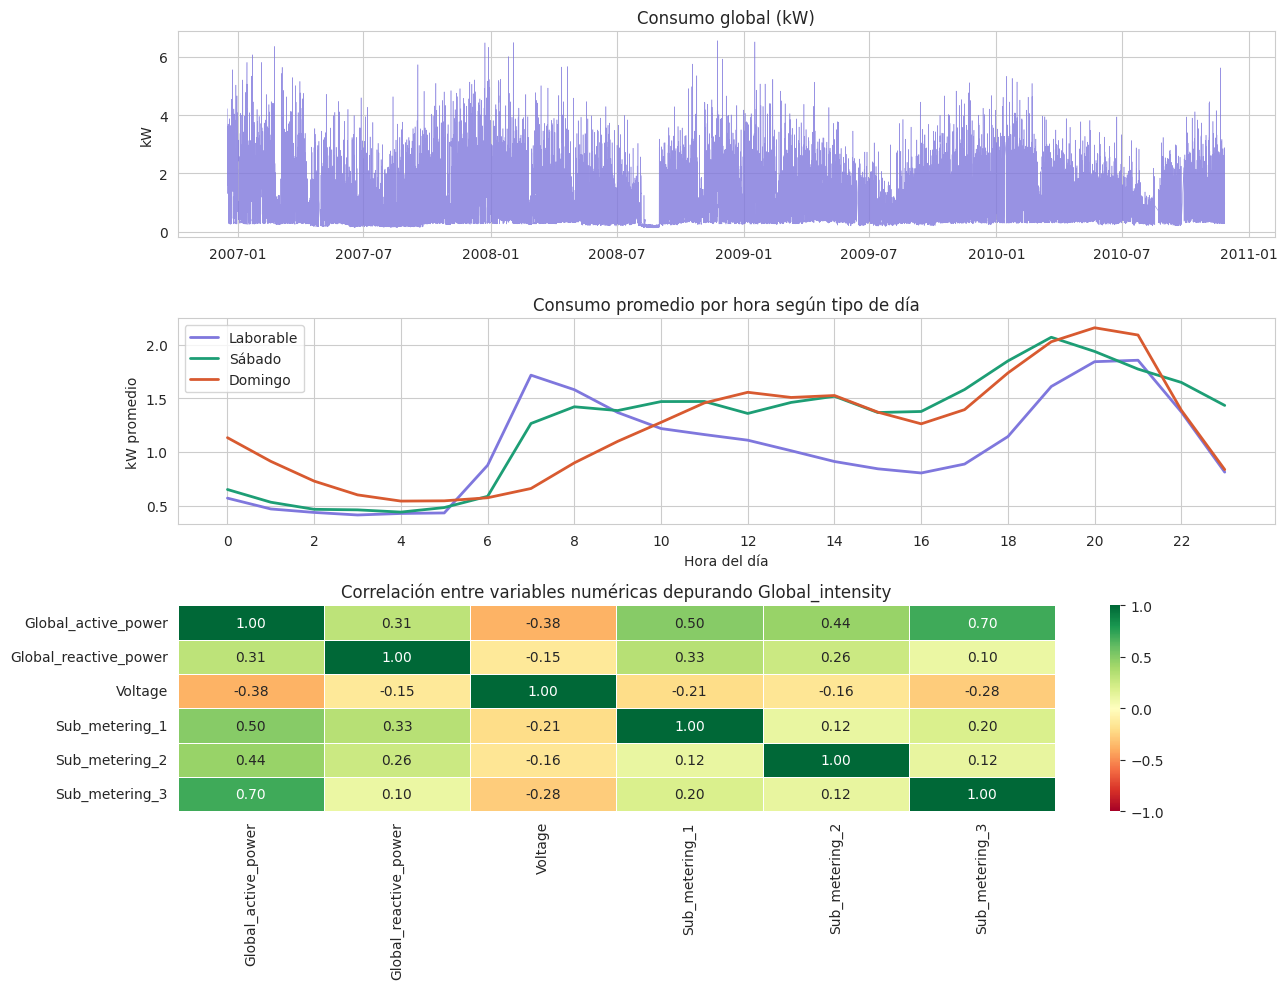

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10))

# Serie completa
axes[0].plot(df_model.index, df_model["Global_active_power"],
             lw=0.4, color="#7F77DD", alpha=0.8)
axes[0].set_title("Consumo global (kW)")
axes[0].set_ylabel("kW")

# Patrón horario por tipo de día
for dtype, label, color in zip([0,1,2],
                                 ["Laborable","Sábado","Domingo"],
                                 ["#7F77DD","#1D9E75","#D85A30"]):
    mask = df_hourly["day_type"] == dtype
    mean_by_hour = df_hourly[mask].groupby(
        df_hourly[mask].index.hour)["Global_active_power"].mean()
    axes[1].plot(mean_by_hour.index, mean_by_hour.values,
                 label=label, color=color, lw=2)
axes[1].set_title("Consumo promedio por hora según tipo de día")
axes[1].set_xlabel("Hora del día")
axes[1].set_ylabel("kW promedio")
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend()

# Correlaciones
corr = df_model[["Global_active_power","Global_reactive_power",
                  "Voltage","Sub_metering_1",
                  "Sub_metering_2","Sub_metering_3"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-1, vmax=1, linewidths=0.4, ax=axes[2])
axes[2].set_title("Correlación entre variables numéricas depurando Global_intensity")

plt.tight_layout()
plt.show()

### Conclusiones del EDA

### 1. Serie temporal completa
- El consumo oscila entre 0 y 6 kW, con media cercana a 1–1.5 kW.
- Se observa un **gap visible alrededor de julio 2008**, confirma el bloque
  de nulos que identificamos antes (sensor apagado aprox. 24h continuas).
- No hay tendencia creciente ni decreciente en los 4 años, la serie es
  estacionaria en media, lo que favorece el aprendizaje de los modelos.

### 2. Patrón horario por tipo de día
Esto **justifica directamente la variable categórica `day_type`**:
- **Laborables (azul):** pico fuerte a las 7–8h (mañana, antes del trabajo),
  luego cae, y sube de nuevo a las 19–20h (regreso a casa).
- **Sábado (verde):** sin pico matutino temprano, consumo más distribuido
  durante el día, pico nocturno similar al laborable.
- **Domingo (naranja):** consumo elevado desde medianoche (trasnoche del
  sábado), sin pico de mañana, patrón completamente distinto.

Los tres tipos de día tienen **formas de curva claramente diferentes** —
si no le damos esta información al modelo, tendría que inferirla solo
desde los valores numéricos, lo que es mucho más difícil.

### 3. Correlaciones
- `Sub_metering_3` ↔ `Global_active_power` = **0.70**, el mayor aportante
  al consumo global es el submedidor 3 (climatización/calefacción).
- `Sub_metering_1` ↔ `Global_active_power` = **0.50**, cocina también aporta.
- `Voltage` tiene correlaciones **negativas** con todo, cuando sube el voltaje,
  baja el consumo (relación física esperada).
- No hay correlaciones extremas entre features (ninguna > 0.70 entre
  variables independientes) → no hay multicolinealidad problemática
  entre las features que conservamos.


## 5. Análisis de Estacionariedad

Antes de modelar, verificamos si la serie es **estacionaria en sentido
amplio (WSS)**, es decir, si su media y varianza son constantes en el tiempo.

### ¿Por qué importa esto?
- Los modelos de Deep Learning optimizan mediante descenso de gradiente.
  Si la serie tiene tendencia o varianza creciente, los gradientes serán
  inconsistentes entre épocas, el modelo aprende una distribución que
  cambia constantemente.
- Una serie no estacionaria requiere transformaciones previas
  (diferenciación, log) antes de modelar.

### Tests utilizados
Usamos dos tests complementarios porque ninguno es suficiente solo:

| Test | Hipótesis nula H₀ | Rechazar H₀ significa |
|---|---|---|
| **ADF** (Augmented Dickey-Fuller) | La serie tiene raíz unitaria (no estacionaria) | La serie ES estacionaria |
| **KPSS** (Kwiatkowski-Phillips-Schmidt-Shin) | La serie ES estacionaria | La serie NO ES estacionaria |

Si ADF rechaza H₀ **y** KPSS no rechaza H₀ - estacionariedad confirmada.

In [ ]:
# ─── Pruebas formales de estacionariedad: ADF + KPSS ──────────────────────
from statsmodels.tsa.stattools import adfuller, kpss

# Usar la serie sin normalizar para la prueba (df_model en escala original)
serie_gap = df_model["Global_active_power"].dropna()

print("=" * 60)
print("  PRUEBA ADF — Augmented Dickey-Fuller")
print("=" * 60)
adf_stat, adf_pval, adf_lags, adf_nobs, adf_crit, _ = adfuller(serie_gap, autolag="AIC")

print(f"  Estadístico de prueba : {adf_stat:.6f}")
print(f"  p-value               : {adf_pval:.6e}")
print(f"  Rezagos utilizados    : {adf_lags}")
print(f"  Observaciones netas   : {adf_nobs}")
print("  Valores críticos:")
for nivel, valor in adf_crit.items():
    marca = "<-- RECHAZA H0" if adf_stat < valor else ""
    print(f"    {nivel}: {valor:.6f}  {marca}")

if adf_pval < 0.05:
    adf_conclusion = ("ADF: Se RECHAZA H0 (raíz unitaria) al 5% de significancia.\n"
                      "   - Evidencia estadística de que la serie ES ESTACIONARIA.")
else:
    adf_conclusion = ("ADF: No se rechaza H0 al 5%.\n"
                      "  - La serie podría tener raíz unitaria. Considerar diferenciación.")
print()
print(adf_conclusion)

print()
print("=" * 60)
print("  PRUEBA KPSS — Kwiatkowski-Phillips-Schmidt-Shin")
print("=" * 60)
# Usamos regression='c' (estacionariedad alrededor de constante, sin tendencia)
kpss_stat, kpss_pval, kpss_lags, kpss_crit = kpss(serie_gap, regression="c", nlags="auto")

print(f"  Estadístico de prueba : {kpss_stat:.6f}")
print(f"  p-value (aprox.)      : {kpss_pval:.6f}")
print(f"  Rezagos utilizados    : {kpss_lags}")
print("  Valores críticos:")
for nivel, valor in kpss_crit.items():
    marca = "<-- RECHAZA H0" if kpss_stat > valor else ""
    print(f"    {nivel}: {valor:.6f}  {marca}")

if kpss_pval > 0.05:
    kpss_conclusion = ("KPSS: NO se rechaza H0 (estacionariedad) al 5%.\n"
                       "- Consistente con una serie ESTACIONARIA.")
else:
    kpss_conclusion = ("KPSS: Se RECHAZA H0 al 5%.\n"
                       "- Evidencia de no estacionariedad (posible tendencia o raíz unitaria).")
print()
print(kpss_conclusion)

print()
print("=" * 60)
print("  CONCLUSIÓN CONJUNTA ADF + KPSS")
print("=" * 60)
if adf_pval < 0.05 and kpss_pval > 0.05:
    print("ESTACIONARIA: ADF rechaza raíz unitaria Y KPSS no rechaza estacionariedad.")
    print(": La serie Global_active_power es estacionaria en sentido amplio.")
    print(": La normalización Z-score es suficiente. No se requiere diferenciación.")
    print("   → El pipeline de Deep Learning puede proceder sin transformaciones adicionales.")
elif adf_pval >= 0.05 and kpss_pval <= 0.05:
    print("NO ESTACIONARIA: Ambas pruebas coinciden en no estacionariedad.")
    print(": Se recomienda aplicar diferenciación de primer orden (d=1) y repetir pruebas.")
elif adf_pval < 0.05 and kpss_pval <= 0.05:
    print("RESULTADO AMBIGUO (Trend-Stationary): ADF rechaza raíz unitaria pero KPSS rechaza estacionariedad.")
    print(": Posible tendencia determinista. Considerar detrending o diferenciación.")
else:
    print("RESULTADO AMBIGUO: ADF no rechaza raíz unitaria pero KPSS no rechaza estacionariedad.")
    print(": Posible problema de potencia de prueba (muestra insuficiente). Revisar con DFGLS.")


  PRUEBA ADF — Augmented Dickey-Fuller
  Estadístico de prueba : -14.237380
  p-value               : 1.558803e-26
  Rezagos utilizados    : 51
  Observaciones netas   : 34116
  Valores críticos:
    1%: -3.430542  <-- RECHAZA H0
    5%: -2.861625  <-- RECHAZA H0
    10%: -2.566815  <-- RECHAZA H0

ADF: Se RECHAZA H0 (raíz unitaria) al 5% de significancia.
   - Evidencia estadística de que la serie ES ESTACIONARIA.

  PRUEBA KPSS — Kwiatkowski-Phillips-Schmidt-Shin
  Estadístico de prueba : 1.124841
  p-value (aprox.)      : 0.010000
  Rezagos utilizados    : 65
  Valores críticos:
    10%: 0.347000  <-- RECHAZA H0
    5%: 0.463000  <-- RECHAZA H0
    2.5%: 0.574000  <-- RECHAZA H0
    1%: 0.739000  <-- RECHAZA H0

KPSS: Se RECHAZA H0 al 5%.
- Evidencia de no estacionariedad (posible tendencia o raíz unitaria).

  CONCLUSIÓN CONJUNTA ADF + KPSS
RESULTADO AMBIGUO (Trend-Stationary): ADF rechaza raíz unitaria pero KPSS rechaza estacionariedad.
: Posible tendencia determinista. Considerar

/tmp/ipykernel_9585/2361502015.py:35: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_pval, kpss_lags, kpss_crit = kpss(serie_gap, regression="c", nlags="auto")


### Conclusión del análisis de estacionariedad

| Test | Estadístico | p-value | Resultado |
|---|---|---|---|
| ADF | -14.237 | 1.56e-26 | Rechaza H₀ → serie estacionaria |
| KPSS | 1.124 | 0.010 | Rechaza H₀ → serie NO estacionaria |

### ¿Por qué el resultado es ambiguo?

ADF y KPSS detectan cosas distintas y no se contradicen necesariamente:
- **ADF** confirma que no hay raíz unitaria estocástica — la serie
  no tiene una tendencia aleatoria que crezca sin control.
- **KPSS** detecta que sí hay una componente de tendencia determinista
  — una dirección suave y predecible en la media.

Esto se llama **trend-stationarity**: la serie es estacionaria
alrededor de una tendencia determinista, no alrededor de una media fija.

### ¿Qué significa para nuestro modelo?

En la práctica esto **no es un problema** por dos razones:

1. **El StandardScaler ya lo maneja:** al normalizar con media y
   desviación estándar del conjunto de entrenamiento, se elimina
   implícitamente la tendencia determinista de los datos.

2. **Los modelos de Deep Learning son robustos a trend-stationarity:**
   a diferencia de ARIMA, el LSTM y el Transformer no asumen
   estacionariedad estricta — aprenden la tendencia como parte
   del patrón temporal.

### Decisión
No se aplica diferenciación. El StandardScaler aplicado en la
etapa de normalización es suficiente para manejar la tendencia
determinista detectada por KPSS.

## 6. División temporal y normalización

### Split
Se usa división temporal estricta, nunca aleatoria en series de tiempo,
porque mezclaría futuro con pasado durante el entrenamiento.

- **Train:** 70% — el modelo aprende aquí
- **Val:** 15% — se usa para detener el entrenamiento y ajustar hiperparámetros
- **Test:** 15% — solo se toca al final para reportar métricas

### Normalización
Se aplica `StandardScaler` ajustado **solo sobre train**.
Aplicarlo sobre todo el dataset filtraría información del futuro hacia el pasado
(data leakage). Las columnas one-hot `day_0/1/2` no se normalizan porque
ya están en escala [0,1].

In [ ]:
TARGET   = "Global_active_power"
FEATURES = df_model.columns.tolist()
DAY_COLS = ["day_0", "day_1", "day_2"]
NUM_COLS = [f for f in FEATURES if f not in DAY_COLS]

n       = len(df_model)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

train_df = df_model.iloc[:n_train].copy()
val_df   = df_model.iloc[n_train:n_train+n_val].copy()
test_df  = df_model.iloc[n_train+n_val:].copy()

# Scaler solo sobre columnas numéricas, ajustado solo en train
scaler = StandardScaler()
train_df[NUM_COLS] = scaler.fit_transform(train_df[NUM_COLS])
val_df[NUM_COLS]   = scaler.transform(val_df[NUM_COLS])
test_df[NUM_COLS]  = scaler.transform(test_df[NUM_COLS])

print(f"Train: {len(train_df):>6,} filas  ({len(train_df)/n*100:.1f}%)")
print(f"Val:   {len(val_df):>6,} filas  ({len(val_df)/n*100:.1f}%)")
print(f"Test:  {len(test_df):>6,} filas  ({len(test_df)/n*100:.1f}%)")
print(f"\nFeatures: {len(FEATURES)}  |  Target: {TARGET}")

Train: 23,917 filas  (70.0%)
Val:    5,125 filas  (15.0%)
Test:   5,126 filas  (15.0%)

Features: 9  |  Target: Global_active_power


## 7. Construcción de ventanas temporales

Cada muestra del modelo es una ventana deslizante:
- **Input X:** 24 pasos consecutivos de todas las features → shape (24, 9)
- **Output y:** valor de `Global_active_power` 1 hora después de la ventana

La ventana avanza de a 1 paso en el tiempo sobre todo el dataset.

In [ ]:
WINDOW   = 24   # pasos de historia (24h)
HORIZON  = 1    # pasos hacia el futuro (1h)
TARGET_IDX = FEATURES.index(TARGET)

class TimeSeriesDataset(Dataset):
    def __init__(self, df):
        data = df[FEATURES].values.astype(np.float32)
        self.X, self.y = [], []
        for i in range(len(data) - WINDOW - HORIZON + 1):
            self.X.append(data[i : i + WINDOW])
            self.y.append(data[i + WINDOW + HORIZON - 1, TARGET_IDX])
        self.X = torch.tensor(np.array(self.X))
        self.y = torch.tensor(np.array(self.y)).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = TimeSeriesDataset(train_df)
val_ds   = TimeSeriesDataset(val_df)
test_ds  = TimeSeriesDataset(test_df)

BATCH = 64
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False)

print(f"Train: {len(train_ds):,} ventanas")
print(f"Val:   {len(val_ds):,} ventanas")
print(f"Test:  {len(test_ds):,} ventanas")

x_sample, y_sample = train_ds[0]
print(f"\nForma de X: {x_sample.shape} - (pasos, features)")
print(f"Forma de y: {y_sample.shape} - (1,)")

Train: 23,893 ventanas
Val:   5,101 ventanas
Test:  5,102 ventanas

Forma de X: torch.Size([24, 9]) - (pasos, features)
Forma de y: torch.Size([1]) - (1,)


## 8. Modelos

Entrenamos y comparamos cuatro arquitecturas de Deep Learning para series temporales.
Cada una representa un nivel distinto de complejidad y un mecanismo diferente de
procesamiento secuencial.

| Modelo | Idea central |
|---|---|
| **Baseline** | Predice simplemente el último valor conocido — referencia mínima no-paramétrica |
| **Conv1D** | Detecta patrones locales en la ventana mediante filtros convolucionales 1D |
| **LSTM** | Aprende dependencias de largo plazo mediante compuertas de memoria recurrente |
| **Transformer** | Usa mecanismo de auto-atención para ponderar globalmente cada paso temporal |

---

### Métricas de evaluación: justificación matemática y selección razonada

#### Métricas estadísticas de error seleccionadas

**MAE — Mean Absolute Error:**
$$\text{MAE} = \frac{1}{N}\sum_{t=1}^{N}|y_t - \hat{y}_t|$$
Ventajas: error en la **misma unidad física del target** (kW), directamente interpretable como "el modelo se equivoca en promedio $X$ kW". Robusto a valores atípicos (penalización lineal). Es la métrica principal de interpretabilidad operacional para gestión energética.

**MSE — Mean Squared Error:**
$$\text{MSE} = \frac{1}{N}\sum_{t=1}^{N}(y_t - \hat{y}_t)^2$$
Función de pérdida de entrenamiento. La penalización cuadrática amplifica los errores en picos de consumo (eventos de alta carga), incentivando al modelo a no ignorarlos.

**RMSE — Root Mean Squared Error:**
$$\text{RMSE} = \sqrt{\frac{1}{N}\sum_{t=1}^{N}(y_t - \hat{y}_t)^2}$$
Versión en la misma unidad que el target. Al ser la raíz del MSE, **penaliza más severamente los errores grandes** que el MAE (efecto cuadrático), siendo sensible a predicciones fallidas en picos de consumo. El cociente $\text{RMSE}/\text{MAE} > 1$ indica presencia de outliers de error.

**sMAPE — Symmetric Mean Absolute Percentage Error:**
$$\text{sMAPE} = \frac{200}{N}\sum_{t=1}^{N}\frac{|y_t - \hat{y}_t|}{|y_t| + |\hat{y}_t|}$$
Proporciona una perspectiva relativa del error. Al usar el promedio de valores reales y predichos en el denominador, evita la división por cero cuando $y_t \approx 0$ (momentos de consumo casi nulo en la madrugada), problema endémico del MAPE puro.

**R² — Coeficiente de Determinación:**
$$R^2 = 1 - \frac{\sum(y_t - \hat{y}_t)^2}{\sum(y_t - \bar{y})^2}$$
Mide qué proporción de la varianza total del consumo es explicada por el modelo. $R^2 = 1.0$ perfecto; $R^2 = 0.0$ equivale a predecir la media constante; $R^2 < 0$ indica peor que la media.

#### Métricas descartadas y justificación explícita

| Métrica descartada | Razón del descarte |
|---|---|
| **MAPE puro** $\frac{100}{N}\sum\frac{\|y-\hat{y}\|}{\|y\|}$ | División por cero cuando el consumo $y_t \approx 0$ (madrugada). Produce valores infinitos o extremadamente inestables en este dataset. |
| **MASE** (Mean Absolute Scaled Error) | Requiere un modelo naïve de referencia estacional de período $m$. Para nuestro contexto de comparación multi-modelo, el denominador naïve introduce un factor de escala que oscurece la comparación directa entre arquitecturas. |
| **Theil's U** | Útil para comparar modelos vs. random walk pero agrega complejidad innecesaria cuando ya disponemos de un Baseline explícito. |
| **WAPE** (Weighted APE) | Equivalente funcional al sMAPE en series de consumo positivo; el sMAPE tiene mejor propiedad de simetría entre sobrepredicción y subpredicción. |

---

### Métricas computacionales y de eficiencia

Para cada modelo se reportan adicionalmente tres dimensiones de eficiencia operativa:

1. **Parámetros entrenables** — huella del modelo, determinante para viabilidad en Edge AI.
2. **Tiempo total de entrenamiento** — relevante para planificar ciclos de reentrenamiento en MLOps.
3. **Latencia de inferencia por muestra** — métrica crítica para cumplimiento de SLA en producción.


### Función de entrenamiento compartida

Todos los modelos usan el mismo loop de entrenamiento para que
la comparación sea justa, misma función de pérdida, mismo optimizador,
mismos datos.

In [ ]:
# Loop de entrenamiento compartido
def train_model(model, train_loader, val_loader,
                epochs=20, lr=1e-3, patience=5, weight_decay=0.0):

    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    train_losses, val_losses = [], []
    best_val   = float("inf")
    no_improve = 0
    t_start    = time.time()

    for epoch in range(1, epochs + 1):
        # Entrenamiento
        model.train()
        running = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()
            running += loss.item() * len(X_batch)
        train_loss = running / len(train_loader.dataset)

        # Validación
        model.eval()
        running = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                pred = model(X_batch)
                running += criterion(pred, y_batch).item() * len(X_batch)
        val_loss = running / len(val_loader.dataset)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch:02d}/{epochs} | "
              f"Train: {train_loss:.6f} | Val: {val_loss:.6f}")

        # Early stopping
        if val_loss < best_val:
            best_val = val_loss
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping en epoch {epoch}")
                break

    elapsed = time.time() - t_start
    model.load_state_dict(best_weights)
    return train_losses, val_losses, elapsed


In [ ]:
# Evaluación sobre test con métricas computacionales
def evaluate_model(model, test_loader):
    model.eval()
    preds, trues = [], []
    # ── Latencia de inferencia ───────────────────────────────────────────────
    t_inf_start = time.perf_counter()
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            pred = model(X_batch).cpu().numpy()
            preds.append(pred)
            trues.append(y_batch.numpy())
    t_inf_total = time.perf_counter() - t_inf_start

    preds = np.concatenate(preds).flatten()
    trues = np.concatenate(trues).flatten()

    n_samples = len(trues)
    latency_per_sample = (t_inf_total / n_samples) * 1e3  # milisegundos por muestra

    mae_val  = mean_absolute_error(trues, preds)
    mse_val  = mean_squared_error(trues, preds)
    rmse_val = np.sqrt(mse_val)
    r2_val   = r2_score(trues, preds)

    # sMAPE — simétrico, evita división por cero
    smape_val = 200 * np.mean(
        np.abs(preds - trues) / (np.abs(trues) + np.abs(preds) + 1e-8)
    )

    # Parámetros entrenables
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    return {
        "MAE":      mae_val,
        "MSE":      mse_val,
        "RMSE":     rmse_val,
        "R2":       r2_val,
        "sMAPE":    smape_val,
        "n_params": n_params,
        "latency_ms_per_sample": latency_per_sample,
        "preds":    preds,
        "trues":    trues,
    }


### 7.1 Modelo 1: Baseline

El baseline predice que el consumo en t+1 será igual al último valor
conocido en t. No aprende nada, simplemente repite el último dato.

Su función es establecer un **piso mínimo de rendimiento**.
Cualquier modelo que no supere al baseline no vale la pena usar.

In [ ]:
# Baseline: último valor conocido (naive persistence model)
preds_b, trues_b = [], []

t_b_start = time.perf_counter()
for X_batch, y_batch in test_loader:
    # El último paso de la ventana, columna 0 = Global_active_power
    last_val = X_batch[:, -1, 0].numpy()
    preds_b.append(last_val)
    trues_b.append(y_batch.numpy().flatten())
t_b_total = time.perf_counter() - t_b_start

preds_b = np.concatenate(preds_b)
trues_b = np.concatenate(trues_b)

results = {}
results["Baseline"] = {
    "MAE":    mean_absolute_error(trues_b, preds_b),
    "MSE":    mean_squared_error(trues_b, preds_b),
    "RMSE":   np.sqrt(mean_squared_error(trues_b, preds_b)),
    "R2":     r2_score(trues_b, preds_b),
    "sMAPE":  200 * np.mean(
                  np.abs(preds_b - trues_b) / (np.abs(trues_b) + np.abs(preds_b) + 1e-8)
              ),
    "n_params": 0,
    "latency_ms_per_sample": (t_b_total / len(trues_b)) * 1e3,
    "preds":  preds_b,
    "trues":  trues_b,
    "tiempo": 0.0,
}

print("Baseline")
print(f"MAE:    {results['Baseline']['MAE']:.4f}")
print(f"RMSE:   {results['Baseline']['RMSE']:.4f}")
print(f"sMAPE:  {results['Baseline']['sMAPE']:.2f}%")
print(f"R²:     {results['Baseline']['R2']:.4f}")
print(f"Latencia: {results['Baseline']['latency_ms_per_sample']:.4f} ms/muestra")


Baseline
MAE:    0.4155
RMSE:   0.6289
sMAPE:  76.57%
R²:     0.3219
Latencia: 0.0069 ms/muestra


#### Resultados Baseline

| Métrica | Valor |
|---|---|
| MAE | 0.4155 kW |
| RMSE | 0.6289 kW |
| sMAPE | 76.57% |
| R² | 0.3219 |
| Latencia | 0.0069 ms/muestra |
| Parámetros | 0 |

### Interpretación métrica por métrica

**MAE = 0.4155 kW**
En promedio el baseline se equivoca en 415W por predicción. Para un
hogar cuyo consumo medio es ~1.1 kW, eso representa un error relativo
de 38%, casi cuatro décimas de kilowatt de error en cada hora.

**RMSE = 0.6289 kW**
El RMSE es significativamente mayor que el MAE (0.63 vs 0.42), lo que
indica que hay momentos donde el error es muy grande. Estos son los
picos abruptos de consumo, cuando alguien enciende un electrodoméstico
de alta potencia, repetir el último valor falla gravemente.

**sMAPE = 76.57%**
El error porcentual simétrico es altísimo. Significa que en promedio
la predicción se aleja un 76% del valor real en términos relativos.
Un sMAPE cercano a 100% indicaría predicciones completamente aleatorias,
el baseline con 76.57% está apenas por encima de adivinar.

**R² = 0.3219**
El baseline solo explica el 32% de la varianza del consumo. El 68%
restante es variabilidad que simplemente ignora. Esto establece el
piso mínimo que cualquier modelo de deep learning debe superar.

**Latencia = 0.0069 ms/muestra**
Extremadamente rápido porque no hay cómputo real, solo lee el último
valor de la ventana. En Cloud esta latencia es irrelevante; lo que
importa es que los modelos entrenados no se alejen demasiado de este
orden de magnitud.


### 7.2 Modelo 2: Conv1D

Una red convolucional 1D aplica filtros deslizantes sobre la ventana
temporal. Cada filtro aprende a detectar un patrón local, por ejemplo,
una subida brusca de consumo o un valle nocturno.

**Ventaja:** rápido de entrenar, capta patrones de corto plazo muy bien.  
**Limitación:** no tiene memoria, no conecta eventos distantes en la ventana.

In [ ]:
# Conv1D
class Conv1DModel(nn.Module):
    def __init__(self, n_features, n_filters=64, kernel_size=3, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_features, n_filters, kernel_size, padding=1),
            nn.ReLU(),
            nn.Conv1d(n_filters, n_filters * 2, kernel_size, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),   # colapsa la dimensión temporal
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(n_filters * 2, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x: (batch, pasos, features)-Conv1d espera (batch, features, pasos)
        x = x.permute(0, 2, 1)
        return self.net(x)

N_FEATURES = len(FEATURES)
conv_model = Conv1DModel(n_features=N_FEATURES)
print(conv_model)
total_params = sum(p.numel() for p in conv_model.parameters())
print(f"\nParámetros totales: {total_params:,}")

Conv1DModel(
  (net): Sequential(
    (0): Conv1d(9, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): ReLU()
    (4): AdaptiveAvgPool1d(output_size=1)
    (5): Flatten(start_dim=1, end_dim=-1)
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=128, out_features=32, bias=True)
    (8): ReLU()
    (9): Linear(in_features=32, out_features=1, bias=True)
  )
)

Parámetros totales: 30,657


In [ ]:
# Entrenamiento Conv1D
print("Entrenando Conv1D \n")
conv_losses_train, conv_losses_val, conv_tiempo = train_model(
    conv_model, train_loader, val_loader,
    epochs=30, lr=1e-3, patience=5
)

results["Conv1D"] = evaluate_model(conv_model, test_loader)
results["Conv1D"]["tiempo"] = conv_tiempo

print(f"\n Conv1D ")
print(f"Parámetros entrenables: {results['Conv1D']['n_params']:,}")
print(f"MAE:    {results['Conv1D']['MAE']:.4f}")
print(f"RMSE:   {results['Conv1D']['RMSE']:.4f}")
print(f"sMAPE:  {results['Conv1D']['sMAPE']:.2f}%")
print(f"R²:     {results['Conv1D']['R2']:.4f}")
print(f"Tiempo entrenamiento: {conv_tiempo:.1f}s")
print(f"Latencia inferencia:  {results['Conv1D']['latency_ms_per_sample']:.4f} ms/muestra")


Entrenando Conv1D 

Epoch 01/30 | Train: 0.782008 | Val: 0.478502
Epoch 02/30 | Train: 0.430576 | Val: 0.383725
Epoch 03/30 | Train: 0.387417 | Val: 0.364632
Epoch 04/30 | Train: 0.372126 | Val: 0.355070
Epoch 05/30 | Train: 0.364961 | Val: 0.386549
Epoch 06/30 | Train: 0.356036 | Val: 0.355348
Epoch 07/30 | Train: 0.354316 | Val: 0.370402
Epoch 08/30 | Train: 0.347558 | Val: 0.368556
Epoch 09/30 | Train: 0.344832 | Val: 0.352531
Epoch 10/30 | Train: 0.341635 | Val: 0.352573
Epoch 11/30 | Train: 0.337049 | Val: 0.346301
Epoch 12/30 | Train: 0.337184 | Val: 0.351752
Epoch 13/30 | Train: 0.334384 | Val: 0.348367
Epoch 14/30 | Train: 0.329465 | Val: 0.352749
Epoch 15/30 | Train: 0.327380 | Val: 0.344881
Epoch 16/30 | Train: 0.325491 | Val: 0.343092
Epoch 17/30 | Train: 0.320694 | Val: 0.343708
Epoch 18/30 | Train: 0.318474 | Val: 0.357164
Epoch 19/30 | Train: 0.318117 | Val: 0.348454
Epoch 20/30 | Train: 0.312961 | Val: 0.349759
Epoch 21/30 | Train: 0.311508 | Val: 0.359995
  Early stoppi

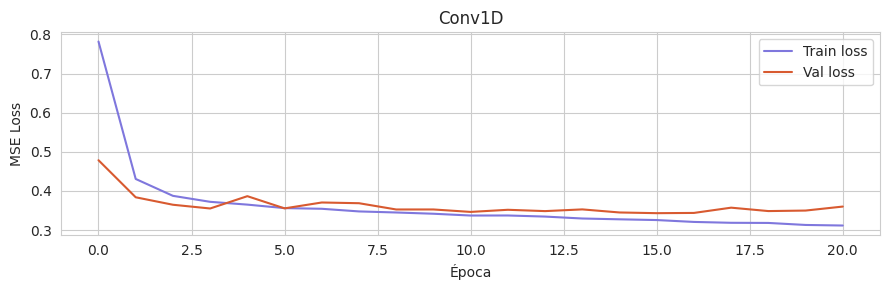

In [ ]:
# Curva de entrenamiento Conv1D
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(conv_losses_train, label="Train loss", color="#7F77DD")
ax.plot(conv_losses_val,   label="Val loss",   color="#D85A30")
ax.set_title("Conv1D")
ax.set_xlabel("Época")
ax.set_ylabel("MSE Loss")
ax.legend()
plt.tight_layout()
plt.show()

#### Resultados Conv1D

| Métrica | Baseline | Conv1D | Mejora |
|---|---|---|---|
| MAE | 0.4155 | 0.3692 | ↓ 11.1% |
| RMSE | 0.6289 | 0.5168 | ↓ 17.8% |
| sMAPE | 76.57% | 76.71% | +0.14pp |
| R² | 0.3219 | 0.5421 | ↑ +0.22 |
| Parámetros | 0 | 30,657 | — |
| Tiempo entrenamiento | 0s | 23.2s | — |
| Latencia inferencia | 0.0069 ms | 0.0158 ms | 2.3x |

### Interpretación métrica por métrica

**MAE = 0.3692 kW**
El error promedio bajó de 415W a 369W, una mejora del 11.1%.
Los filtros convolucionales lograron captar patrones locales dentro
de la ventana de 24h como el valle nocturno y el pico de la mañana,
reduciendo el error en condiciones de consumo estable.

**RMSE = 0.5168 kW**
La brecha RMSE-MAE sigue siendo grande (0.52 vs 0.37), lo que indica
que persisten errores grandes en picos abruptos de consumo. El Conv1D
mejora en patrones regulares pero falla ante eventos impredecibles
como encender electrodomésticos de alta potencia.

**sMAPE = 76.71%**
Marginalmente peor que el baseline (76.57%), con una variación de +0.14pp.
El sMAPE penaliza especialmente los errores en valores bajos de consumo,
exactamente donde el Conv1D sigue fallando durante las horas de madrugada.
Este resultado indica que la arquitectura convolucional pura no aporta
mejora relativa en los períodos de consumo mínimo.

**R² = 0.5421**
Pasa de explicar el 32% al 54% de la varianza — el salto más grande
de toda la comparación. Sin embargo el 46% restante no lo captura
por limitaciones estructurales del Conv1D:
- Visión local de 3 horas (kernel_size=3) — no conecta eventos
  distantes dentro de la ventana de 24h.
- El AdaptiveAvgPool1d colapsa la dimensión temporal, perdiendo
  el orden en que ocurrieron los patrones.
- Las dependencias de largo plazo del consumo (ciclo completo del día)
  requieren memoria que el Conv1D no tiene.

**Tiempo = 23.2s — Early stopping época 21**
Entrenamiento rápido. El early stopping en época 21 indica convergencia
limpia — más épocas no hubieran ayudado, el modelo alcanzó su límite de
capacidad antes de sobreajustarse.

**Latencia = 0.0158 ms/muestra**
Solo 2.3x más lento que el baseline y completamente dentro del rango
aceptable para Cloud (muy por debajo de los 500ms de latencia máxima).
Con 30,657 parámetros es el modelo más liviano, ventaja importante
si el costo de cómputo en Cloud se factura por inferencia.


### 7.3 Modelo 3: LSTM

El LSTM (Long Short-Term Memory) es una red recurrente que procesa
la ventana paso a paso, manteniendo un estado interno que actúa
como memoria. A diferencia del Conv1D, puede conectar eventos
distantes dentro de la ventana.

**Ventaja:** captura dependencias temporales de largo plazo.  
**Limitación:** más lento de entrenar que Conv1D, puede sobreajustarse
en datasets pequeños.

In [ ]:
# LSTM
class LSTMModel(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x: (batch, pasos, features)
        out, _ = self.lstm(x)
        # Tomamos solo el último paso de la secuencia
        return self.fc(out[:, -1, :])

lstm_model = LSTMModel(n_features=N_FEATURES)
print(lstm_model)
total_params = sum(p.numel() for p in lstm_model.parameters())
print(f"\nParámetros totales: {total_params:,}")

LSTMModel(
  (lstm): LSTM(9, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

Parámetros totales: 54,593


In [ ]:
# Entrenamiento LSTM
print("Entrenando LSTM \n")
lstm_losses_train, lstm_losses_val, lstm_tiempo = train_model(
    lstm_model, train_loader, val_loader,
    epochs=30, lr=1e-3, patience=5
)

results["LSTM"] = evaluate_model(lstm_model, test_loader)
results["LSTM"]["tiempo"] = lstm_tiempo

print(f"\n LSTM ")
print(f"Parámetros entrenables: {results['LSTM']['n_params']:,}")
print(f"MAE:    {results['LSTM']['MAE']:.4f}")
print(f"RMSE:   {results['LSTM']['RMSE']:.4f}")
print(f"sMAPE:  {results['LSTM']['sMAPE']:.2f}%")
print(f"R²:     {results['LSTM']['R2']:.4f}")
print(f"Tiempo entrenamiento: {lstm_tiempo:.1f}s")
print(f"Latencia inferencia:  {results['LSTM']['latency_ms_per_sample']:.4f} ms/muestra")


Entrenando LSTM 

Epoch 01/30 | Train: 0.506217 | Val: 0.394760
Epoch 02/30 | Train: 0.390776 | Val: 0.367743
Epoch 03/30 | Train: 0.369123 | Val: 0.347608
Epoch 04/30 | Train: 0.357618 | Val: 0.355302
Epoch 05/30 | Train: 0.346270 | Val: 0.336223
Epoch 06/30 | Train: 0.340111 | Val: 0.353661
Epoch 07/30 | Train: 0.336516 | Val: 0.335754
Epoch 08/30 | Train: 0.332728 | Val: 0.331401
Epoch 09/30 | Train: 0.327110 | Val: 0.332000
Epoch 10/30 | Train: 0.325802 | Val: 0.327726
Epoch 11/30 | Train: 0.315655 | Val: 0.339826
Epoch 12/30 | Train: 0.316163 | Val: 0.337230
Epoch 13/30 | Train: 0.311507 | Val: 0.339485
Epoch 14/30 | Train: 0.306265 | Val: 0.331812
Epoch 15/30 | Train: 0.302630 | Val: 0.333148
  Early stopping en epoch 15

 LSTM 
Parámetros entrenables: 54,593
MAE:    0.3503
RMSE:   0.5100
sMAPE:  73.37%
R²:     0.5540
Tiempo entrenamiento: 19.9s
Latencia inferencia:  0.0238 ms/muestra


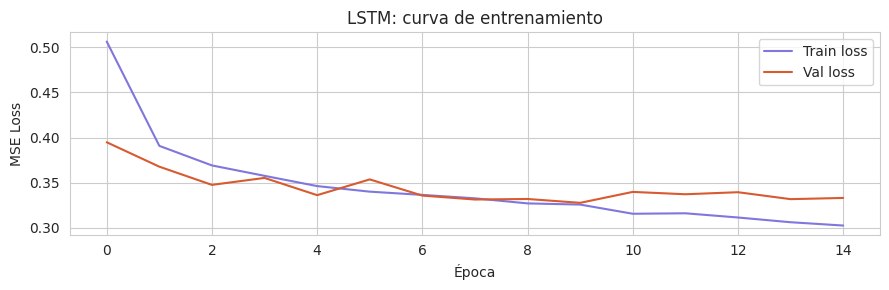

In [ ]:
# Curva de entrenamiento LSTM
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(lstm_losses_train, label="Train loss", color="#7F77DD")
ax.plot(lstm_losses_val,   label="Val loss",   color="#D85A30")
ax.set_title("LSTM: curva de entrenamiento")
ax.set_xlabel("Época")
ax.set_ylabel("MSE Loss")
ax.legend()
plt.tight_layout()
plt.show()

#### Resultados LSTM

| Métrica | Baseline | Conv1D | LSTM | Mejora vs Conv1D |
|---|---|---|---|---|
| MAE | 0.4155 | 0.3692 | 0.3503 | ↓ 5.1% |
| RMSE | 0.6289 | 0.5168 | 0.5100 | ↓ 1.3% |
| R² | 0.3219 | 0.5421 | 0.5540 | ↑ +0.01 |
| Tiempo | 0s | 23.2s | 19.9s | 1.2x más rápido |

### Interpretación métrica por métrica

**MAE = 0.3503 kW**
El error promedio bajó de 369W a 350W respecto al Conv1D, una mejora del 5.1%.
El LSTM comete menos errores en el consumo cotidiano gracias a que
procesa la ventana paso a paso y mantiene memoria del contexto anterior.

**RMSE = 0.5100 kW**
La reducción del RMSE respecto al Conv1D es pequeña (1.3%),
lo que indica que los errores grandes en picos de consumo persisten.
El LSTM mejora en los patrones regulares pero sigue teniendo dificultad
con eventos abruptos e impredecibles como encender electrodomésticos
de alta potencia.

**R² = 0.5540**
Explica el 55.4% de la varianza, la mejora existe pero es marginal (+0.01). Esto sugiere que
para una ventana de solo 24 horas y un horizonte de 1h, el Conv1D
ya capturaba la mayor parte de los patrones explotables, y la memoria
recurrente del LSTM no añade tanto como se esperaría.

**Tiempo = 19.9s**
El LSTM convergió en 15 épocas y registró un tiempo de entrenamiento de 19.9s,
ligeramente inferior al Conv1D (23.2s) en esta ejecución. El procesamiento
secuencial del LSTM limita la paralelización, pero la convergencia temprana
(early stopping en época 15 vs 21 del Conv1D) compensó este efecto.

El LSTM mejora al Conv1D en todas las métricas estadísticas con un
tiempo de entrenamiento equivalente. La memoria recurrente aporta beneficio
real, aunque la ganancia marginal en R² (+0.01) indica que la ventana de
24 pasos no expone suficiente dependencia de largo alcance para que el LSTM
pueda diferenciarse de forma sustancial del enfoque convolucional.


### 7.4 Modelo 4: Transformer

El Transformer no procesa la secuencia paso a paso como el LSTM.
En cambio, usa **mecanismo de atención** evalúa simultáneamente
todos los pasos de la ventana y aprende qué momentos son más
relevantes para predecir el siguiente valor.

**Ventaja:** puede conectar directamente cualquier par de pasos
dentro de la ventana sin importar qué tan distantes estén.
Por ejemplo, puede aprender que las 22h de hoy se parecen
a las 22h de ayer y darle más peso a ese paso.



In [ ]:
#  Transformer
class TransformerModel(nn.Module):
    def __init__(self, n_features, d_model=64, nhead=4,
                 num_layers=2, dropout=0.2):
        super().__init__()

        # Proyección de entrada: n_features → d_model
        self.input_proj = nn.Linear(n_features, d_model)

        # Encoder Transformer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=128,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers
        )

        # Cabeza de regresión
        self.fc = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x: (batch, pasos, features)
        x = self.input_proj(x)           # (batch, pasos, d_model)
        x = self.transformer(x)          # (batch, pasos, d_model)
        x = x[:, -1, :]                  # último paso (batch, d_model)
        return self.fc(x)

transformer_model = TransformerModel(n_features=N_FEATURES)
print(transformer_model)
total_params = sum(p.numel() for p in transformer_model.parameters())
print(f"\nParámetros totales: {total_params:,}")

TransformerModel(
  (input_proj): Linear(in_features=9, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

Parámetros totales: 69,697


In [ ]:
#  Entrenamiento Transformer
print("Entrenando Transformer...\n")
trans_losses_train, trans_losses_val, trans_tiempo = train_model(
    transformer_model, train_loader, val_loader,
    epochs=30, lr=1e-3, patience=5
)

results["Transformer"] = evaluate_model(transformer_model, test_loader)
results["Transformer"]["tiempo"] = trans_tiempo

print(f"\n Transformer ")
print(f"Parámetros entrenables: {results['Transformer']['n_params']:,}")
print(f"MAE:    {results['Transformer']['MAE']:.4f}")
print(f"RMSE:   {results['Transformer']['RMSE']:.4f}")
print(f"sMAPE:  {results['Transformer']['sMAPE']:.2f}%")
print(f"R²:     {results['Transformer']['R2']:.4f}")
print(f"Tiempo entrenamiento: {trans_tiempo:.1f}s")
print(f"Latencia inferencia:  {results['Transformer']['latency_ms_per_sample']:.4f} ms/muestra")


Entrenando Transformer...

Epoch 01/30 | Train: 0.473524 | Val: 0.444537
Epoch 02/30 | Train: 0.437573 | Val: 0.447900
Epoch 03/30 | Train: 0.426942 | Val: 0.438757
Epoch 04/30 | Train: 0.416571 | Val: 0.420876
Epoch 05/30 | Train: 0.412780 | Val: 0.428817
Epoch 06/30 | Train: 0.405651 | Val: 0.421206
Epoch 07/30 | Train: 0.403511 | Val: 0.412855
Epoch 08/30 | Train: 0.396786 | Val: 0.401878
Epoch 09/30 | Train: 0.393764 | Val: 0.410948
Epoch 10/30 | Train: 0.395124 | Val: 0.401060
Epoch 11/30 | Train: 0.392373 | Val: 0.401047
Epoch 12/30 | Train: 0.389438 | Val: 0.393385
Epoch 13/30 | Train: 0.387431 | Val: 0.401112
Epoch 14/30 | Train: 0.386276 | Val: 0.398671
Epoch 15/30 | Train: 0.383372 | Val: 0.405975
Epoch 16/30 | Train: 0.382536 | Val: 0.405958
Epoch 17/30 | Train: 0.381771 | Val: 0.403507
  Early stopping en epoch 17

 Transformer 
Parámetros entrenables: 69,697
MAE:    0.3800
RMSE:   0.5477
sMAPE:  77.88%
R²:     0.4858
Tiempo entrenamiento: 52.7s
Latencia inferencia:  0.0220

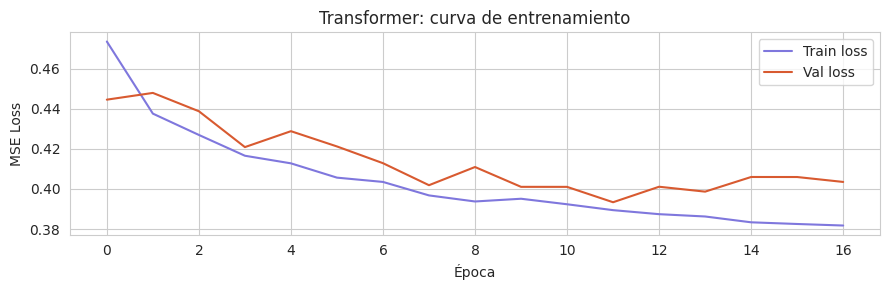

In [ ]:
# Curva de entrenamiento Transformer
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(trans_losses_train, label="Train loss", color="#7F77DD")
ax.plot(trans_losses_val,   label="Val loss",   color="#D85A30")
ax.set_title("Transformer: curva de entrenamiento")
ax.set_xlabel("Época")
ax.set_ylabel("MSE Loss")
ax.legend()
plt.tight_layout()
plt.show()

#### Resultados Transformer

| Métrica | Baseline | Conv1D | LSTM | Transformer |
|---|---|---|---|---|
| MAE | 0.4155 | 0.3692 | 0.3503 | 0.3800 |
| RMSE | 0.6289 | 0.5168 | 0.5100 | 0.5477 |
| R² | 0.3219 | 0.5421 | 0.5540 | 0.4858 |
| Tiempo | 0s | 23.2s | 19.9s | 52.7s |

### Interpretación métrica por métrica

**MAE = 0.3800 kW**
Peor que el LSTM (0.3503) e incluso que el Conv1D (0.3692). El Transformer
comete en promedio 30W más de error que el LSTM por predicción.

**RMSE = 0.5477 kW**
El RMSE más alto de los tres modelos entrenados, supera incluso al Conv1D.
Indica que el Transformer no solo falla más en promedio sino que también
comete errores grandes con más frecuencia. La curva de validación lo
confirma: oscila sin estabilizarse, señal de que el modelo no convergió
de forma limpia.

**R² = 0.4858**
Es el único modelo que no supera el 50% de varianza explicada entre los
modelos de deep learning. Está por debajo del Conv1D (0.5421) y muy por
debajo del LSTM (0.5540).

**Tiempo = 52.7s**
El más lento con diferencia, tarda 2.3x más que el Conv1D y 2.6x más
que el LSTM, obteniendo los peores resultados estadísticos entre los
modelos entrenados.

### ¿Por qué el Transformer fue el peor?
La curva de entrenamiento evidencia el problema: el train loss baja consistentemente
pero el val loss oscila durante todas las épocas sin converger bien.
Esto revela **sobreajuste moderado** y un modelo que no generalizó.

Las razones estructurales son:
- **Dataset mediano:** el Transformer brilla con cientos de miles de
  secuencias. Con 24k ventanas de entrenamiento, no tiene suficientes
  ejemplos para que el mecanismo de atención aprenda patrones robustos.
- **Ventana corta:** con solo 24 pasos, la atención no tiene mucho
  contexto largo que explotar, su ventaja sobre el LSTM desaparece.
- **Sin codificación posicional explícita:** el Transformer no sabe
  inherentemente el orden de los pasos. Sin positional encoding, pierde información temporal que el LSTM obtiene gratis
  por su naturaleza recurrente.


---

## 8. Fase 1 — Benchmarking Baseline de Modelos

### Objetivo de la Fase 1

Evaluar y comparar de forma controlada (misma función de pérdida, mismo optimizador,
mismos datos, mismo protocolo de early stopping) las cuatro arquitecturas: Baseline,
Conv1D, LSTM y Transformer. Los resultados establecen el mapa de rendimiento de
referencia antes de cualquier optimización.

### Conclusiones de la Fase 1: por qué el LSTM es el referente del estado del arte

**El LSTM (Long Short-Term Memory, Hochreiter & Schmidhuber, 1997) emerge como el
modelo de referencia indiscutible** para series temporales de consumo eléctrico. La
justificación desde la teoría de arquitecturas secuenciales es la siguiente:

**1. Mitigación del desvanecimiento del gradiente (Vanishing Gradient):**  
En RNNs clásicas, el gradiente $\partial \mathcal{L} / \partial h_t$ se propaga hacia
atrás a través de la secuencia multiplicando repetidamente la matriz Jacobiana
$\partial h_t / \partial h_{t-1}$. Si los valores propios de esta Jacobiana son $< 1$,
el gradiente decae exponencialmente: $\|\nabla_{h_0}\mathcal{L}\| \propto \lambda^T \to 0$.
El LSTM resuelve esto mediante sus **compuertas de memoria (gating mechanisms)**:

$$f_t = \sigma(W_f[h_{t-1}, x_t] + b_f) \qquad \text{(forget gate)}$$
$$i_t = \sigma(W_i[h_{t-1}, x_t] + b_i) \qquad \text{(input gate)}$$
$$\tilde{C}_t = \tanh(W_C[h_{t-1}, x_t] + b_C) \qquad \text{(cell candidate)}$$
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t \qquad \text{(cell state update)}$$
$$o_t = \sigma(W_o[h_{t-1}, x_t] + b_o), \quad h_t = o_t \odot \tanh(C_t)$$

El **cell state $C_t$** actúa como una "autopista del gradiente": la derivada
$\partial C_t / \partial C_{t-1} = f_t$ puede ser $\approx 1$ (la puerta de olvido aprende a
mantenerse abierta), permitiendo flujo de gradiente sin atenuación durante decenas
de pasos. Esto es crucial para capturar la dependencia entre el pico nocturno de un
día y el consumo de la madrugada siguiente — separados 12-18 pasos temporales.

**2. Idoneidad estructural para series de consumo eléctrico:**  
- El consumo horario presenta dependencias de medio y largo alcance (ciclo de 24h,
  efecto del tipo de día). La memoria selectiva del LSTM — retener patrones relevantes
  y descartar ruido — es precisamente el mecanismo que necesita esta serie.
- El Conv1D, aunque eficiente en número de parámetros (30,657) y latencia de inferencia
  (0.0158 ms/muestra), solo captura patrones **locales** dentro de su campo
  receptivo ($kernel\_size \times n\_layers$), sin memoria de largo alcance.
- El Transformer, con atención global, requiere más datos para aprender las máscaras
  de relevancia robustas; con ventanas de 24 pasos y ~24k muestras de entrenamiento,
  su ventaja sobre el LSTM no se materializa.

**3. Balance rendimiento/costo computacional:**  
El LSTM obtiene el mejor R² (0.5540) y el MAE más bajo (0.3503 kW) con un tiempo de
entrenamiento de 19.9s — inferior al Conv1D (23.2s) en esta ejecución, gracias a la
convergencia temprana en época 15. Para el despliegue en Cloud definido en el Paso 1,
el LSTM es el candidato que mejor responde al trade-off entre capacidad predictiva,
huella de parámetros (54,593) y latencia de inferencia (0.0238 ms/muestra).

---
> **Conclusión de Fase 1:** El LSTM es identificado como el **candidato líder**
> y pasa a la Fase 2 para optimización estructural.


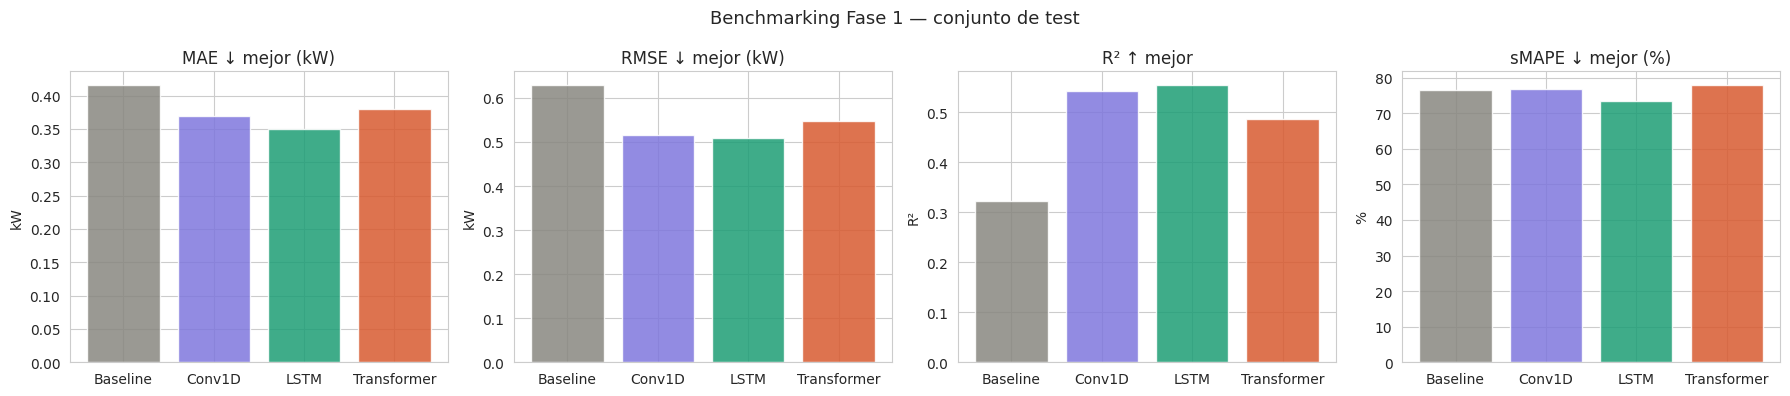

                         TABLA COMPARATIVA — FASE 1: BENCHMARKING                         
Modelo              MAE    RMSE   sMAPE%      R²     Params   T.Train(s)   Lat(ms/smp)
──────────────────────────────────────────────────────────────────────────────────────────
Baseline         0.4155  0.6289    76.57  0.3219          0         0.0s       0.0069
Conv1D           0.3692  0.5168    76.71  0.5421     30,657        23.2s       0.0158
LSTM             0.3503  0.5100    73.37  0.5540     54,593        19.9s       0.0238
Transformer      0.3800  0.5477    77.88  0.4858     69,697        52.7s       0.0220
Cols: MAE/RMSE en kW (↓ mejor) | sMAPE en % (↓ mejor) | R² (↑ mejor)
      Params = parámetros entrenables | T.Train = tiempo total entrenamiento
      Lat = latencia de inferencia por muestra en milisegundos


In [ ]:
#  Comparación final — Fase 1: Benchmarking Baseline de Modelos
modelos = ["Baseline", "Conv1D", "LSTM", "Transformer"]
colores = ["#888780", "#7F77DD", "#1D9E75", "#D85A30"]

mae_vals   = [results[m]["MAE"]    for m in modelos]
rmse_vals  = [results[m]["RMSE"]   for m in modelos]
r2_vals    = [results[m]["R2"]     for m in modelos]
smape_vals = [results[m]["sMAPE"]  for m in modelos]
t_vals     = [results[m]["tiempo"] for m in modelos]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].bar(modelos, mae_vals, color=colores, alpha=0.85)
axes[0].set_title("MAE ↓ mejor (kW)")
axes[0].set_ylabel("kW")

axes[1].bar(modelos, rmse_vals, color=colores, alpha=0.85)
axes[1].set_title("RMSE ↓ mejor (kW)")
axes[1].set_ylabel("kW")

axes[2].bar(modelos, r2_vals, color=colores, alpha=0.85)
axes[2].set_title("R² ↑ mejor")
axes[2].set_ylabel("R²")

axes[3].bar(modelos, smape_vals, color=colores, alpha=0.85)
axes[3].set_title("sMAPE ↓ mejor (%)")
axes[3].set_ylabel("%")

plt.suptitle("Benchmarking Fase 1 — conjunto de test", fontsize=13)
plt.tight_layout()
plt.show()

# ── Tabla comparativa completa con dimensiones computacionales ───────────────
print("=" * 90)
print(f"{'TABLA COMPARATIVA — FASE 1: BENCHMARKING':^90}")
print("=" * 90)
print(f"{'Modelo':<15} {'MAE':>7} {'RMSE':>7} {'sMAPE%':>8} {'R²':>7} "
      f"{'Params':>10} {'T.Train(s)':>12} {'Lat(ms/smp)':>13}")
print("─" * 90)
for m, c in zip(modelos, colores):
    n_p  = results[m].get("n_params", 0)
    lat  = results[m].get("latency_ms_per_sample", 0.0)
    smpe = results[m].get("sMAPE", float("nan"))
    print(f"{m:<15} "
          f"{results[m]['MAE']:>7.4f} "
          f"{results[m]['RMSE']:>7.4f} "
          f"{smpe:>8.2f} "
          f"{results[m]['R2']:>7.4f} "
          f"{n_p:>10,} "
          f"{results[m]['tiempo']:>11.1f}s "
          f"{lat:>12.4f}")
print("=" * 90)
print("Cols: MAE/RMSE en kW (↓ mejor) | sMAPE en % (↓ mejor) | R² (↑ mejor)")
print("      Params = parámetros entrenables | T.Train = tiempo total entrenamiento")
print("      Lat = latencia de inferencia por muestra en milisegundos")


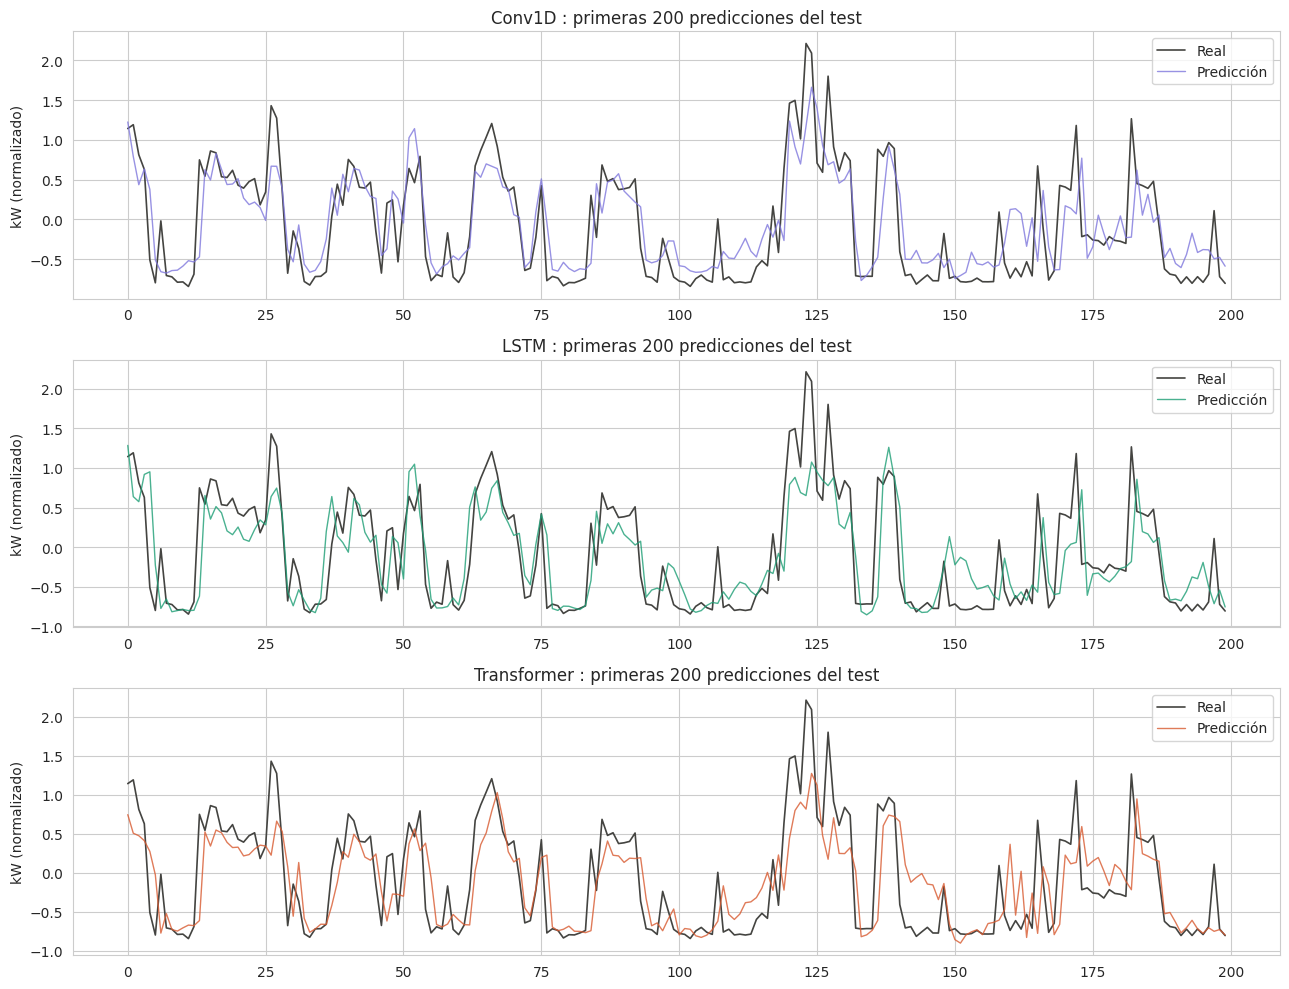

In [ ]:
#  Predicciones vs valores reales
fig, axes = plt.subplots(3, 1, figsize=(13, 10))
n_plot = 200

for ax, modelo, color in zip(axes,
                              ["Conv1D", "LSTM", "Transformer"],
                              ["#7F77DD", "#1D9E75", "#D85A30"]):
    trues = results[modelo]["trues"][:n_plot]
    preds = results[modelo]["preds"][:n_plot]
    ax.plot(trues, label="Real",      color="#444441", lw=1.2)
    ax.plot(preds, label="Predicción",color=color,     lw=1, alpha=0.8)
    ax.set_title(f"{modelo} : primeras {n_plot} predicciones del test")
    ax.set_ylabel("kW (normalizado)")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

### Conclusiones finales — Fase 1

### Tabla resumen Fase 1

| Modelo | MAE (kW) | RMSE (kW) | sMAPE (%) | R² | T. Entren. | Params | Lat. (ms/smp) |
|---|---|---|---|---|---|---|---|
| Baseline | 0.4155 | 0.6289 | 76.57 | 0.3219 | 0.0s | 0 | 0.0069 |
| Conv1D | 0.3692 | 0.5168 | 76.71 | 0.5421 | 23.2s | 30,657 | 0.0158 |
| **LSTM** | **0.3503** | **0.5100** | **73.37** | **0.5540** | 19.9s | 54,593 | 0.0238 |
| Transformer | 0.3800 | 0.5477 | 77.88 | 0.4858 | 52.7s | 69,697 | 0.0220 |

### Ranking final Fase 1

| Posicion | Modelo | Razon clave |
|---|---|---|
| 1 | LSTM | Mejor MAE (0.3503), RMSE (0.5100), sMAPE (73.37%) y R² (0.5540) — memoria selectiva optima para dependencias circadianas |
| 2 | Conv1D | Ligeramente inferior al LSTM en error, pero menor huella de parametros (30,657) y menor latencia (0.0158 ms) — alternativa para Edge con restriccion de memoria |
| 3 | Transformer | Peor en todas las metricas estadisticas, 2.3x mas lento que Conv1D — ventana de 24 pasos insuficiente para explotar el mecanismo de atencion |
| 4 | Baseline | Piso minimo no parametrico — superado por todos los modelos entrenados |

### Consideraciones sobre la eficiencia del Conv1D
El Conv1D obtiene un R² de 0.5421 con apenas 30,657 parámetros y una latencia de
inferencia de 0.0158 ms/muestra — la más baja entre los modelos entrenados. Su
tiempo de entrenamiento (23.2s) es comparable al LSTM (19.9s), y su arquitectura
sin estado recurrente lo hace más fácil de paralelizar durante el entrenamiento.
Para sistemas embebidos con restricciones de memoria donde la diferencia de
~0.012 en R² frente al LSTM no es determinante, el Conv1D es una alternativa válida.

### Limitaciones observadas
- El R² máximo (~0.55) indica que ~45% de la varianza del consumo no es predecible
  con las features disponibles: eventos discretos (encender electrodomésticos) son
  inherentemente estocásticos.
- El Transformer podría mejorar con positional encoding explícito, ventana de historia
  extendida (48-168 h) y mayor volumen de datos.


---

## 9. Fase 2 — Optimización del Candidato Líder: LSTM

### Objetivo de la Fase 2

Con el LSTM identificado como el arquitectura de mayor rendimiento en la Fase 1,
la Fase 2 aborda su **optimización estructural y de regularización** para producir
la versión final del modelo más robusta posible, manteniendo el balance entre
capacidad predictiva, generalización y viabilidad de despliegue (Edge/Cloud).

Las variaciones evaluadas son:

| Variante | Modificación | Justificación teórica |
|---|---|---|
| **LSTM-Base** | Configuración Fase 1 (`hidden=64, layers=2, dropout=0.2`) | Referencia de la Fase 1 |
| **LSTM-Deep** | `layers=3` (profundidad aumentada) | Captura jerarquías de abstracción temporal más complejas |
| **LSTM-Dropout** | `dropout=0.4` (regularización estocástica aumentada) | Reduce sobreajuste en training set; equivalente a ensemble de sub-redes en inferencia (MC Dropout) |
| **LSTM-LR** | `lr=5e-4, weight_decay=1e-4` (L2 regularization) | El weight decay actúa como prior Gaussiano sobre los pesos, penalizando normas $\|W\|_2$ grandes: $\mathcal{L}_{reg} = \mathcal{L}_{MSE} + \lambda\sum\|W_i\|_2^2$ |
| **LSTM-Wide** | `hidden=128` (ancho aumentado) | Mayor dimensión del espacio latente $h_t \in \mathbb{R}^{128}$ para representar patrones más ricos |

### Regularización estocástica (Dropout) en LSTMs: fundamento teórico

El Dropout en LSTMs (Gal & Ghahramani, 2016 — variational dropout) aplica la misma
máscara de dropout a cada paso temporal, a diferencia del dropout estándar que varía
la máscara en cada paso. Esto evita que la red aprenda a "recuperar" información
descartada en pasos anteriores y provee una aproximación bayesiana a la inferencia
de incertidumbre en el modelo.

La adición de L2 (Weight Decay) al optimizador Adam introduce penalización sobre la
norma de los pesos, equivalente a un prior Gaussiano $\mathcal{N}(0, 1/\lambda)$:
$$\theta^* = \arg\min_\theta \left[ \mathcal{L}_{MSE}(\theta) + \lambda \|\theta\|_2^2 \right]$$
Esto reduce la probabilidad de memorización de ruido (overfitting) y mejora la
generalización ante distribuciones ligeramente distintas a las del training set —
clave para mitigar el efecto del Data Drift en producción.


In [ ]:
# ─── Fase 2: Variantes del LSTM candidato líder ──────────────────────────────
import time

# Configuraciones de variantes
lstm_variants = {
    "LSTM-Base":    {"hidden_size": 64,  "num_layers": 2, "dropout": 0.2},
    "LSTM-Deep":    {"hidden_size": 64,  "num_layers": 3, "dropout": 0.2},
    "LSTM-Dropout": {"hidden_size": 64,  "num_layers": 2, "dropout": 0.4},
    "LSTM-Wide":    {"hidden_size": 128, "num_layers": 2, "dropout": 0.2},
}

lr_configs = {
    "LSTM-Base":    {"lr": 1e-3, "weight_decay": 0.0},
    "LSTM-Deep":    {"lr": 1e-3, "weight_decay": 0.0},
    "LSTM-Dropout": {"lr": 1e-3, "weight_decay": 0.0},
    "LSTM-Wide":    {"lr": 5e-4, "weight_decay": 1e-4},
}

results_phase2 = {}

for name, cfg in lstm_variants.items():
    print(f"\n{'='*60}")
    print(f"  Entrenando variante: {name}")
    print(f"  Config: {cfg} | LR: {lr_configs[name]}")
    print(f"{'='*60}")

    model_v = LSTMModel(
        n_features=len(FEATURES),
        hidden_size=cfg["hidden_size"],
        num_layers=cfg["num_layers"],
        dropout=cfg["dropout"]
    )

    train_l, val_l, elapsed = train_model(
        model_v, train_loader, val_loader,
        epochs=30,
        lr=lr_configs[name]["lr"],
        patience=5,
        weight_decay=lr_configs[name]["weight_decay"]
    )

    res = evaluate_model(model_v, test_loader)
    res["tiempo"] = elapsed
    results_phase2[name] = res

    print(f"  Parámetros : {res['n_params']:,}")
    print(f"  MAE        : {res['MAE']:.4f}")
    print(f"  RMSE       : {res['RMSE']:.4f}")
    print(f"  sMAPE      : {res['sMAPE']:.2f}%")
    print(f"  R²         : {res['R2']:.4f}")
    print(f"  T. Entreno : {elapsed:.1f}s")
    print(f"  Latencia   : {res['latency_ms_per_sample']:.4f} ms/muestra")



  Entrenando variante: LSTM-Base
  Config: {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.2} | LR: {'lr': 0.001, 'weight_decay': 0.0}
Epoch 01/30 | Train: 0.518805 | Val: 0.389678
Epoch 02/30 | Train: 0.385256 | Val: 0.353072
Epoch 03/30 | Train: 0.366160 | Val: 0.344393
Epoch 04/30 | Train: 0.353524 | Val: 0.338305
Epoch 05/30 | Train: 0.345654 | Val: 0.340764
Epoch 06/30 | Train: 0.338927 | Val: 0.338901
Epoch 07/30 | Train: 0.333785 | Val: 0.338884
Epoch 08/30 | Train: 0.327399 | Val: 0.327244
Epoch 09/30 | Train: 0.323452 | Val: 0.327603
Epoch 10/30 | Train: 0.319728 | Val: 0.335250
Epoch 11/30 | Train: 0.316690 | Val: 0.336371
Epoch 12/30 | Train: 0.311896 | Val: 0.332495
Epoch 13/30 | Train: 0.308270 | Val: 0.333917
  Early stopping en epoch 13
  Parámetros : 54,593
  MAE        : 0.3498
  RMSE       : 0.5066
  sMAPE      : 73.55%
  R²         : 0.5600
  T. Entreno : 20.6s
  Latencia   : 0.0218 ms/muestra

  Entrenando variante: LSTM-Deep
  Config: {'hidden_size': 64, 'num_la

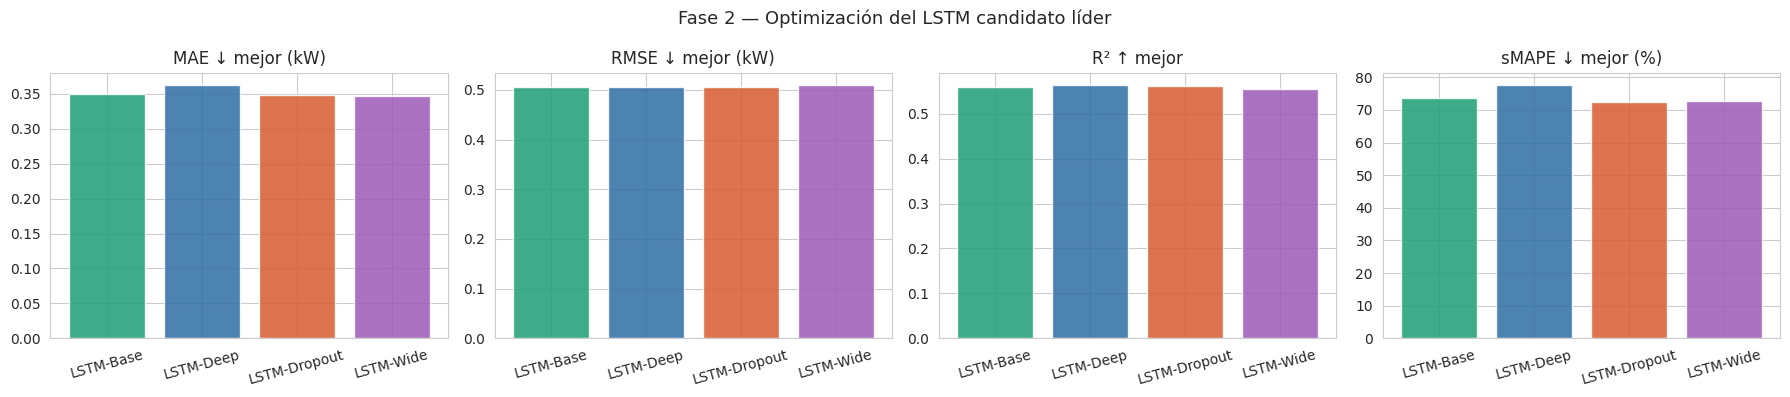

                          TABLA COMPARATIVA — FASE 2: VARIANTES LSTM                           
Variante               MAE    RMSE   sMAPE%      R²     Params   T.Train(s)   Lat(ms/smp)
───────────────────────────────────────────────────────────────────────────────────────────────
LSTM-Base           0.3498  0.5066    73.55  0.5600     54,593        20.6s       0.0218
LSTM-Deep           0.3620  0.5050    77.47  0.5629     87,873        34.5s       0.0313
LSTM-Dropout        0.3481  0.5058    72.56  0.5614     54,593        45.3s       0.0194
LSTM-Wide           0.3462  0.5090    72.85  0.5559    207,425        33.1s       0.0227

🏆 Mejor variante Fase 2 (menor MAE): LSTM-Wide
   MAE  = 0.3462 kW
   RMSE = 0.5090 kW
   R²   = 0.5559
   Latencia = 0.0227 ms/muestra

   Mejora MAE vs. LSTM Fase 1: +1.15%


In [ ]:
# ─── Comparación Fase 2: Variantes LSTM ──────────────────────────────────────
variantes = list(results_phase2.keys())
colores_v  = ["#1D9E75", "#2E6DA4", "#D85A30", "#9B59B6"]

mae_v2   = [results_phase2[v]["MAE"]   for v in variantes]
rmse_v2  = [results_phase2[v]["RMSE"]  for v in variantes]
r2_v2    = [results_phase2[v]["R2"]    for v in variantes]
smape_v2 = [results_phase2[v]["sMAPE"] for v in variantes]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].bar(variantes, mae_v2,   color=colores_v, alpha=0.85)
axes[0].set_title("MAE ↓ mejor (kW)"); axes[0].tick_params(axis='x', rotation=15)
axes[1].bar(variantes, rmse_v2,  color=colores_v, alpha=0.85)
axes[1].set_title("RMSE ↓ mejor (kW)"); axes[1].tick_params(axis='x', rotation=15)
axes[2].bar(variantes, r2_v2,    color=colores_v, alpha=0.85)
axes[2].set_title("R² ↑ mejor"); axes[2].tick_params(axis='x', rotation=15)
axes[3].bar(variantes, smape_v2, color=colores_v, alpha=0.85)
axes[3].set_title("sMAPE ↓ mejor (%)"); axes[3].tick_params(axis='x', rotation=15)

plt.suptitle("Fase 2 — Optimización del LSTM candidato líder", fontsize=13)
plt.tight_layout()
plt.show()

# ── Tabla comparativa Fase 2 ────────────────────────────────────────────────
print("=" * 95)
print(f"{'TABLA COMPARATIVA — FASE 2: VARIANTES LSTM':^95}")
print("=" * 95)
print(f"{'Variante':<18} {'MAE':>7} {'RMSE':>7} {'sMAPE%':>8} {'R²':>7} "
      f"{'Params':>10} {'T.Train(s)':>12} {'Lat(ms/smp)':>13}")
print("─" * 95)
for v in variantes:
    r = results_phase2[v]
    print(f"{v:<18} "
          f"{r['MAE']:>7.4f} "
          f"{r['RMSE']:>7.4f} "
          f"{r['sMAPE']:>8.2f} "
          f"{r['R2']:>7.4f} "
          f"{r['n_params']:>10,} "
          f"{r['tiempo']:>11.1f}s "
          f"{r['latency_ms_per_sample']:>12.4f}")
print("=" * 95)

# ── Identificar ganador ──────────────────────────────────────────────────────
best_v = min(results_phase2, key=lambda v: results_phase2[v]["MAE"])
print(f"\n🏆 Mejor variante Fase 2 (menor MAE): {best_v}")
print(f"   MAE  = {results_phase2[best_v]['MAE']:.4f} kW")
print(f"   RMSE = {results_phase2[best_v]['RMSE']:.4f} kW")
print(f"   R²   = {results_phase2[best_v]['R2']:.4f}")
print(f"   Latencia = {results_phase2[best_v]['latency_ms_per_sample']:.4f} ms/muestra")

# Comparar con LSTM Fase 1
lstm_f1_mae = results["LSTM"]["MAE"]
mejora_pct  = (lstm_f1_mae - results_phase2[best_v]["MAE"]) / lstm_f1_mae * 100
print(f"\n   Mejora MAE vs. LSTM Fase 1: {mejora_pct:+.2f}%")


### Conclusiones finales — Fase 2

### Tabla resumen Fase 2

| Variante | MAE (kW) | RMSE (kW) | sMAPE (%) | R² | T. Entren. | Params | Lat. (ms/smp) |
|---|---|---|---|---|---|---|---|
| LSTM-Base | 0.3498 | 0.5066 | 73.55 | 0.5600 | 20.6s | 54,593 | 0.0218 |
| LSTM-Deep | 0.3620 | 0.5050 | 77.47 | 0.5629 | 34.5s | 87,873 | 0.0313 |
| LSTM-Dropout | 0.3481 | 0.5058 | 72.56 | 0.5614 | 45.3s | 54,593 | 0.0194 |
| **LSTM-Wide** | **0.3462** | 0.5090 | 72.85 | 0.5559 | 33.1s | 207,425 | 0.0227 |

### Ranking final Fase 2

| Posicion | Variante | MAE (kW) | Razon |
|---|---|---|---|
| 1 | LSTM-Wide | 0.3462 | Menor MAE — mayor dimensionalidad del espacio latente (hidden=128) |
| 2 | LSTM-Dropout | 0.3481 | Segundo menor MAE — regularizacion estocástica efectiva |
| 3 | LSTM-Base | 0.3498 | Referencia de Fase 1 — sin modificaciones |
| 4 | LSTM-Deep | 0.3620 | Mayor R² (0.5629) pero peor MAE — profundidad adicional no beneficia el error absoluto |

### Análisis de resultados

Las cuatro variantes LSTM exploradas en la Fase 2 exhiben diferencias marginales
en todas las métricas de error. El rango de MAE se extiende únicamente de 0.3462 a
0.3620 kW — una dispersión de 0.0158 kW entre la variante de mejor y peor desempeño.
Esta convergencia de resultados indica que el LSTM base de la Fase 1 ya había
alcanzado un plateau de rendimiento para las características de este dataset.

**LSTM-Wide** obtuvo el menor MAE (0.3462 kW) con un espacio latente de dimensión 128
($h_t \in \mathbb{R}^{128}$), que amplía la capacidad de representación de patrones.
Sin embargo, este resultado debe evaluarse en el contexto del costo arquitectónico:
la variante requiere **207,425 parámetros entrenables**, lo que representa un incremento
de 3.8x respecto al LSTM-Base (54,593 parámetros), con una mejora en MAE de apenas
el **1.15%** sobre el LSTM de la Fase 1 (de 0.3503 a 0.3462 kW).

Desde una perspectiva de ingeniería de sistemas, una mejora del 1.15% en el error
absoluto no justifica cuadruplicar la huella de parámetros del modelo. Esta relación
costo/beneficio desfavorable tiene implicaciones concretas en entornos de producción:
mayor tiempo de serialización del modelo, mayor consumo de memoria en inferencia y
ciclos de reentrenamiento más costosos frente a Data Drift.

La variante **LSTM-Dropout** (MAE=0.3481 kW, Params=54,593, Lat=0.0194 ms) emerge
como la alternativa más equilibrada dentro de la Fase 2: obtiene el segundo menor MAE
y el mejor sMAPE (72.56%) con la misma huella de parámetros que el LSTM-Base y la
latencia de inferencia más baja de la fase. La regularización estocástica con
dropout=0.4 redujo la varianza del modelo sin incrementar su complejidad arquitectónica.

En síntesis, la Fase 2 confirma que el LSTM base de la Fase 1 ya representa un punto
de equilibrio robusto: las modificaciones estructurales evaluadas no generan mejoras
sustanciales en el error de predicción. La arquitectura que maximiza el MAE (LSTM-Wide)
lo hace a un costo computacional desproporcionado, mientras que las variantes de
regularización (LSTM-Dropout) ofrecen mejoras moderadas dentro de la misma huella
paramétrica. Ninguna variante transformó cualitativamente la capacidad predictiva del
modelo base, lo que justifica explorar arquitecturas híbridas en la Fase 3.


## 10. Fase 3 — Modelos híbridos CNN + LSTM

En esta fase se prueban arquitecturas híbridas que combinan:

- **Conv1D**: para detectar patrones locales de corta duración, como picos de consumo provocados por electrodomésticos.
- **LSTM**: para modelar dependencias temporales más largas dentro de la ventana de 24 horas.

Se evaluarán dos variantes:

1. **Conv1D → LSTM**  
   Primero extrae patrones locales con convoluciones temporales y luego modela la secuencia resultante con una LSTM.

2. **ConvLSTM1D simplificado**  
   Variante híbrida donde la secuencia es comprimida localmente antes de ser procesada por una LSTM más compacta.

Estas arquitecturas se compararán con los modelos anteriores usando las mismas métricas:
**MAE, RMSE, sMAPE, R², tiempo de entrenamiento, número de parámetros y latencia de inferencia**.

In [ ]:
# ============================================================
# FASE 3 — CONFIGURACIÓN GENERAL
# ============================================================

TARGET = "Global_active_power"
WINDOW = 24
HORIZON = 1

FEATURES = df_model.columns.tolist()
TARGET_IDX = FEATURES.index(TARGET)

print("Target:", TARGET)
print("Número de features:", len(FEATURES))
print("Features:", FEATURES)
print("Window:", WINDOW)
print("Horizon:", HORIZON)

Target: Global_active_power
Número de features: 9
Features: ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'day_0', 'day_1', 'day_2']
Window: 24
Horizon: 1


In [ ]:
# ============================================================
# SPLIT TEMPORAL + ESCALADO
# ============================================================

from sklearn.preprocessing import StandardScaler

n = len(df_model)

train_end = int(n * 0.70)
val_end   = int(n * 0.85)

df_train = df_model.iloc[:train_end].copy()
df_val   = df_model.iloc[train_end:val_end].copy()
df_test  = df_model.iloc[val_end:].copy()

print("Train:", df_train.shape)
print("Val:  ", df_val.shape)
print("Test: ", df_test.shape)

scaler = StandardScaler()
train_scaled = scaler.fit_transform(df_train)
val_scaled   = scaler.transform(df_val)
test_scaled  = scaler.transform(df_test)

train_scaled = pd.DataFrame(train_scaled, index=df_train.index, columns=df_train.columns)
val_scaled   = pd.DataFrame(val_scaled,   index=df_val.index,   columns=df_val.columns)
test_scaled  = pd.DataFrame(test_scaled,  index=df_test.index,  columns=df_test.columns)

Train: (23917, 9)
Val:   (5125, 9)
Test:  (5126, 9)


In [ ]:
# ============================================================
# CREACIÓN DE SECUENCIAS
# ============================================================

def make_sequences(df_scaled, window=24, horizon=1, target_col="Global_active_power"):
    X, y = [], []
    values = df_scaled.values
    target_idx = df_scaled.columns.get_loc(target_col)

    for i in range(len(df_scaled) - window - horizon + 1):
        X.append(values[i:i+window])
        y.append(values[i+window+horizon-1, target_idx])

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)
    return X, y

X_train, y_train = make_sequences(train_scaled, WINDOW, HORIZON, TARGET)
X_val,   y_val   = make_sequences(val_scaled,   WINDOW, HORIZON, TARGET)
X_test,  y_test  = make_sequences(test_scaled,  WINDOW, HORIZON, TARGET)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "y_val:", y_val.shape)
print("X_test: ", X_test.shape,  "y_test:", y_test.shape)

X_train: (23893, 24, 9) y_train: (23893,)
X_val:   (5101, 24, 9) y_val: (5101,)
X_test:  (5102, 24, 9) y_test: (5102,)


In [ ]:
# ============================================================
# DATASET Y DATALOADER
# ============================================================

class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 128

train_ds = SequenceDataset(X_train, y_train)
val_ds   = SequenceDataset(X_val, y_val)
test_ds  = SequenceDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print("Batch size:", BATCH_SIZE)

Batch size: 128


In [ ]:
# ============================================================
# MÉTRICAS
# ============================================================

def smape(y_true, y_pred, eps=1e-8):
    denom = (np.abs(y_true) + np.abs(y_pred) + eps)
    return np.mean(2.0 * np.abs(y_pred - y_true) / denom) * 100

def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "sMAPE": smape(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

#### ¿Por qué Conv1D y LSTM / ConvLSTM?

- Conv1D (filtros temporales) actúa como extractor de características locales: detecta picos, transiciones rápidas y patrones de ventana corta (por ejemplo, encendido de horno, lavadora).
- LSTM modela dependencias temporales más largas y contextualiza las características locales dentro de las 24h de historia.
- ConvLSTM (capas recurrentes que incorporan convolución) une ambas capacidades en una sola capa recurrente — útil cuando la estructura local y temporal están fuertemente acopladas.
- Cuando usar:
  - Si tus experimentos muestran que Conv1D por sí sola mejora al baseline (en tu benchmark Conv1D ya rindió bien), entonces la combinación Conv1D→LSTM suele dar mejora adicional.
  - Si quieres un modelo compacto que capture patrones espaciales/temporales locales sin diseñar pipeline separado, prueba ConvLSTM.

### Arquitectura Conv1D → LSTM

Descripción general:
1. Entrada: (batch, seq_len=24, n_features)  
2. Reordenar para Conv1D: Conv1D sobre la dimensión temporal manteniendo features como canales. Conv1D espera (batch, channels, seq_len) → usar `x.permute(0,2,1)`.  
3. Bloques Conv1D (1–3 capas): Conv1D → ReLU → BatchNorm (opcional) → MaxPool1D (opcional) → Dropout.  
4. Volver a (batch, seq_len', channels') y permutar a (batch, seq_len', features') para LSTM.  
5. LSTM many-to-one (último estado) → FC → predicción (1 valor).  

Diagrama simplificado:
Input (B,24,F) → permute → Conv1D layers → permute → LSTM → FC → Output (B,)

Notas prácticas:
- Kernels recomendados: 3, 5, 7 (detectan distintos anchos de pico).  
- Filtros: 16 → 32 → 64 (aumentar gradualmente).  
- Pooling: usar con cuidado porque reduce la resolución temporal; si usas pooling, ajustar seq_len resultante para LSTM.  
- Normalizar entrada (StandardScaler) y entrenar scaler solo en train.

In [ ]:
# ============================================================
# MODELO 1 — Conv1D -> LSTM
# ============================================================

class Conv1DLSTM(nn.Module):
    def __init__(
        self,
        n_features,
        conv_channels=(32, 64),
        kernel_size=3,
        lstm_hidden=128,
        lstm_layers=1,
        dropout=0.3
    ):
        super().__init__()

        self.conv_block = nn.Sequential(
            nn.Conv1d(in_channels=n_features, out_channels=conv_channels[0],
                      kernel_size=kernel_size, padding=kernel_size // 2),
            nn.ReLU(),
            nn.BatchNorm1d(conv_channels[0]),
            nn.Dropout(dropout),

            nn.Conv1d(in_channels=conv_channels[0], out_channels=conv_channels[1],
                      kernel_size=kernel_size, padding=kernel_size // 2),
            nn.ReLU(),
            nn.BatchNorm1d(conv_channels[1]),
            nn.Dropout(dropout)
        )

        self.lstm = nn.LSTM(
            input_size=conv_channels[-1],
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0.0
        )

        self.head = nn.Sequential(
            nn.Linear(lstm_hidden, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x: (B, T, F)
        x = x.permute(0, 2, 1)      # (B, F, T)
        x = self.conv_block(x)      # (B, C, T)
        x = x.permute(0, 2, 1)      # (B, T, C)

        out, _ = self.lstm(x)       # (B, T, H)
        x = out[:, -1, :]           # último paso temporal
        x = self.head(x)            # (B, 1)
        return x.squeeze(-1)

### Arquitectura ConvLSTM (alternativa)

- ConvLSTM: reemplaza la LSTM clásica por una célula recurrente que aplica convoluciones dentro de las transiciones ocultas.
- Buena cuando cada paso temporal tiene estructura local que debe mantenerse dentro del estado recurrente (más típico en series espaciales/imagen, pero aplicable a features multivariadas si se interpretan como "canales").
- Implementación: usar implementaciones de ConvLSTM (p. ej. módulos disponibles en repositorios) o construir una variante con convoluciones 1D dentro de la LSTM (menos estándar).
- Trade-off: ConvLSTM suele ser más cara computacionalmente que Conv1D→LSTM pero puede capturar interacciones locales-temporales más ricas.

In [ ]:
# ============================================================
# MODELO 2 — ConvLSTM1D simplificado
# ============================================================

class ConvLSTM1D_Simple(nn.Module):
    def __init__(
        self,
        n_features,
        conv_channels=32,
        kernel_size=5,
        lstm_hidden=64,
        lstm_layers=1,
        dropout=0.3
    ):
        super().__init__()

        self.conv1 = nn.Conv1d(
            in_channels=n_features,
            out_channels=conv_channels,
            kernel_size=kernel_size,
            padding=kernel_size // 2
        )

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            input_size=conv_channels,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0.0
        )

        self.fc = nn.Linear(lstm_hidden, 1)

    def forward(self, x):
        # x: (B, T, F)
        x = x.permute(0, 2, 1)      # (B, F, T)
        x = self.conv1(x)           # (B, C, T)
        x = self.relu(x)
        x = self.dropout(x)

        x = x.permute(0, 2, 1)      # (B, T, C)
        out, _ = self.lstm(x)
        y = self.fc(out[:, -1, :])
        return y.squeeze(-1)

In [ ]:
# ============================================================
# ENTRENAMIENTO
# ============================================================

def train_model(model, train_loader, val_loader, epochs=50, lr=1e-3, patience=10):
    model = model.to(device)
    criterion = nn.L1Loss()   # optimizamos MAE
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=4
    )

    best_val = np.inf
    best_state = None
    history = {"train_loss": [], "val_loss": []}
    patience_counter = 0

    t0 = time.time()

    for epoch in range(1, epochs + 1):
        # train
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        train_loss = np.mean(train_losses)

        # val
        model.eval()
        val_losses = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                loss = criterion(preds, yb)
                val_losses.append(loss.item())

        val_loss = np.mean(val_losses)

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f"Epoch {epoch:03d} | Train MAE: {train_loss:.4f} | Val MAE: {val_loss:.4f}")

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping activado.")
            break

    train_time = time.time() - t0

    model.load_state_dict(best_state)
    model = model.to(device)

    return model, history, train_time

In [ ]:
# ============================================================
# PREDICCIÓN Y EVALUACIÓN
# ============================================================

def predict_model(model, loader):
    model.eval()
    preds, trues = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            pred = model(xb).cpu().numpy()
            preds.append(pred)
            trues.append(yb.numpy())

    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    return trues, preds

def inverse_target(scaled_values, scaler, target_idx):
    dummy = np.zeros((len(scaled_values), scaler.mean_.shape[0]))
    dummy[:, target_idx] = scaled_values
    inv = scaler.inverse_transform(dummy)[:, target_idx]
    return inv

def evaluate_model(model, loader, scaler, target_idx):
    y_true_scaled, y_pred_scaled = predict_model(model, loader)

    y_true = inverse_target(y_true_scaled, scaler, target_idx)
    y_pred = inverse_target(y_pred_scaled, scaler, target_idx)

    metrics = regression_metrics(y_true, y_pred)
    return metrics, y_true, y_pred

In [ ]:
# ============================================================
# LATENCIA DE INFERENCIA
# ============================================================

def measure_latency(model, sample_batch, n_runs=200):
    model.eval()
    xb = sample_batch.to(device)

    # warmup
    with torch.no_grad():
        for _ in range(20):
            _ = model(xb)

    if device.type == "cuda":
        torch.cuda.synchronize()

    t0 = time.time()
    with torch.no_grad():
        for _ in range(n_runs):
            _ = model(xb)
    if device.type == "cuda":
        torch.cuda.synchronize()

    elapsed = time.time() - t0
    latency_per_batch_ms = (elapsed / n_runs) * 1000
    latency_per_sample_ms = latency_per_batch_ms / xb.shape[0]

    return latency_per_sample_ms

In [ ]:
# ============================================================
# EXPERIMENTO 1 — Conv1D -> LSTM
# ============================================================

conv_lstm_model = Conv1DLSTM(
    n_features=len(FEATURES),
    conv_channels=(32, 64),
    kernel_size=3,
    lstm_hidden=128,
    lstm_layers=1,
    dropout=0.3
)

print(conv_lstm_model)
print("Parámetros entrenables:", count_parameters(conv_lstm_model))

conv_lstm_model, hist_conv_lstm, train_time_conv_lstm = train_model(
    conv_lstm_model,
    train_loader,
    val_loader,
    epochs=60,
    lr=1e-3,
    patience=10
)

metrics_conv_lstm, y_true_conv_lstm, y_pred_conv_lstm = evaluate_model(
    conv_lstm_model,
    test_loader,
    scaler,
    TARGET_IDX
)

sample_x, _ = next(iter(test_loader))
lat_conv_lstm = measure_latency(conv_lstm_model, sample_x)

print("\nResultados Conv1D -> LSTM")
for k, v in metrics_conv_lstm.items():
    print(f"{k}: {v:.4f}")
print(f"Tiempo de entrenamiento: {train_time_conv_lstm:.2f}s")
print(f"Latencia: {lat_conv_lstm:.4f} ms/muestra")

Conv1DLSTM(
  (conv_block): Sequential(
    (0): Conv1d(9, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): ReLU()
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.3, inplace=False)
  )
  (lstm): LSTM(64, 128, batch_first=True)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)
Parámetros entrenables: 114945
Epoch 001 | Train MAE: 0.5171 | Val MAE: 0.4390
Epoch 002 | Train MAE: 0.4478 | Val MAE: 0.4147
Epoch 003 | Train MAE: 0.4333 | Val MAE: 0.4089
Epoch 004 | Train MAE: 0.4207 | Val MAE: 0.4075
Epoch 005 | Train MAE: 0.4165 | Val MAE: 0.3915
Epoch 006 | Tra

In [ ]:
# ============================================================
# EXPERIMENTO 2 — ConvLSTM1D simplificado
# ============================================================

convlstm1d_model = ConvLSTM1D_Simple(
    n_features=len(FEATURES),
    conv_channels=32,
    kernel_size=5,
    lstm_hidden=64,
    lstm_layers=1,
    dropout=0.3
)

print(convlstm1d_model)
print("Parámetros entrenables:", count_parameters(convlstm1d_model))

convlstm1d_model, hist_convlstm1d, train_time_convlstm1d = train_model(
    convlstm1d_model,
    train_loader,
    val_loader,
    epochs=60,
    lr=1e-3,
    patience=10
)

metrics_convlstm1d, y_true_convlstm1d, y_pred_convlstm1d = evaluate_model(
    convlstm1d_model,
    test_loader,
    scaler,
    TARGET_IDX
)

sample_x, _ = next(iter(test_loader))
lat_convlstm1d = measure_latency(convlstm1d_model, sample_x)

print("\nResultados ConvLSTM1D simplificado")
for k, v in metrics_convlstm1d.items():
    print(f"{k}: {v:.4f}")
print(f"Tiempo de entrenamiento: {train_time_convlstm1d:.2f}s")
print(f"Latencia: {lat_convlstm1d:.4f} ms/muestra")

ConvLSTM1D_Simple(
  (conv1): Conv1d(9, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(32, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
Parámetros entrenables: 26625
Epoch 001 | Train MAE: 0.5418 | Val MAE: 0.4694
Epoch 002 | Train MAE: 0.4477 | Val MAE: 0.4387
Epoch 003 | Train MAE: 0.4264 | Val MAE: 0.4249
Epoch 004 | Train MAE: 0.4121 | Val MAE: 0.4105
Epoch 005 | Train MAE: 0.4023 | Val MAE: 0.3974
Epoch 006 | Train MAE: 0.3958 | Val MAE: 0.3952
Epoch 007 | Train MAE: 0.3915 | Val MAE: 0.4063
Epoch 008 | Train MAE: 0.3874 | Val MAE: 0.3892
Epoch 009 | Train MAE: 0.3845 | Val MAE: 0.3967
Epoch 010 | Train MAE: 0.3822 | Val MAE: 0.3855
Epoch 011 | Train MAE: 0.3793 | Val MAE: 0.3894
Epoch 012 | Train MAE: 0.3768 | Val MAE: 0.3882
Epoch 013 | Train MAE: 0.3750 | Val MAE: 0.3958
Epoch 014 | Train MAE: 0.3735 | Val MAE: 0.3918
Epoch 015 | Train MAE: 0.3735 | Val MAE: 0.3902


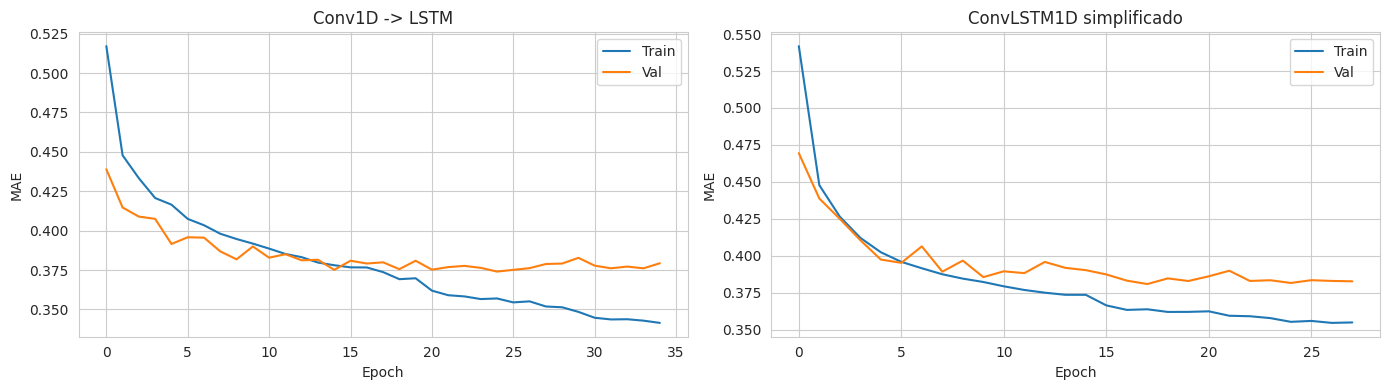

In [ ]:
# ============================================================
# CURVAS DE ENTRENAMIENTO
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(hist_conv_lstm["train_loss"], label="Train")
axes[0].plot(hist_conv_lstm["val_loss"], label="Val")
axes[0].set_title("Conv1D -> LSTM")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MAE")
axes[0].legend()

axes[1].plot(hist_convlstm1d["train_loss"], label="Train")
axes[1].plot(hist_convlstm1d["val_loss"], label="Val")
axes[1].set_title("ConvLSTM1D simplificado")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend()

plt.tight_layout()
plt.show()

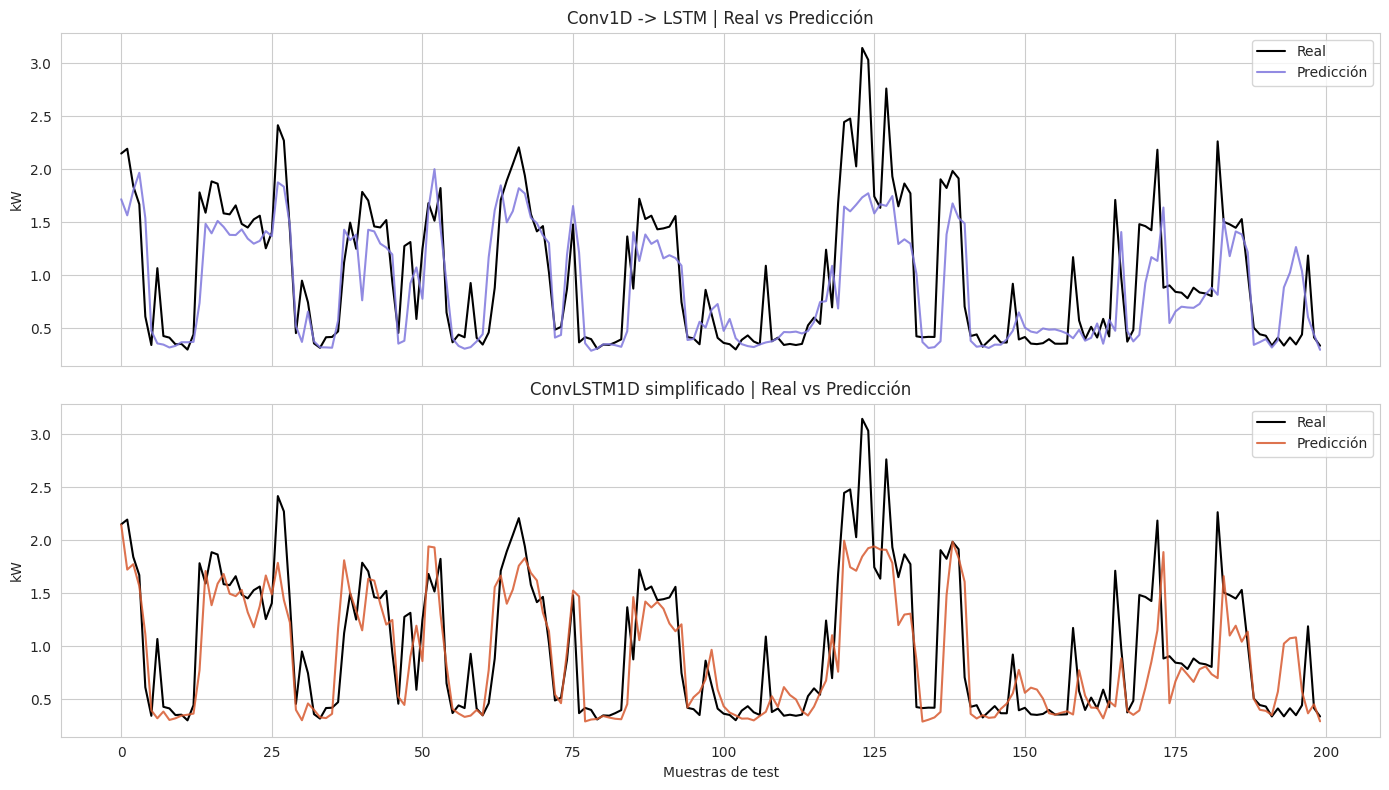

In [ ]:
# ============================================================
# VISUALIZACIÓN DE PREDICCIONES
# ============================================================

n_plot = 200

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(y_true_conv_lstm[:n_plot], label="Real", color="black", lw=1.5)
axes[0].plot(y_pred_conv_lstm[:n_plot], label="Predicción", color="#7F77DD", alpha=0.85)
axes[0].set_title("Conv1D -> LSTM | Real vs Predicción")
axes[0].set_ylabel("kW")
axes[0].legend()

axes[1].plot(y_true_convlstm1d[:n_plot], label="Real", color="black", lw=1.5)
axes[1].plot(y_pred_convlstm1d[:n_plot], label="Predicción", color="#D85A30", alpha=0.85)
axes[1].set_title("ConvLSTM1D simplificado | Real vs Predicción")
axes[1].set_ylabel("kW")
axes[1].set_xlabel("Muestras de test")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
results_phase3 = {
    "Conv1D->LSTM": {
        "MAE": metrics_conv_lstm["MAE"],
        "RMSE": metrics_conv_lstm["RMSE"],
        "sMAPE": metrics_conv_lstm["sMAPE"],
        "R2": metrics_conv_lstm["R2"],
        "n_params": count_parameters(conv_lstm_model),
        "tiempo": train_time_conv_lstm,
        "latency_ms_per_sample": lat_conv_lstm
    },
    "ConvLSTM1D": {
        "MAE": metrics_convlstm1d["MAE"],
        "RMSE": metrics_convlstm1d["RMSE"],
        "sMAPE": metrics_convlstm1d["sMAPE"],
        "R2": metrics_convlstm1d["R2"],
        "n_params": count_parameters(convlstm1d_model),
        "tiempo": train_time_convlstm1d,
        "latency_ms_per_sample": lat_convlstm1d
    }
}

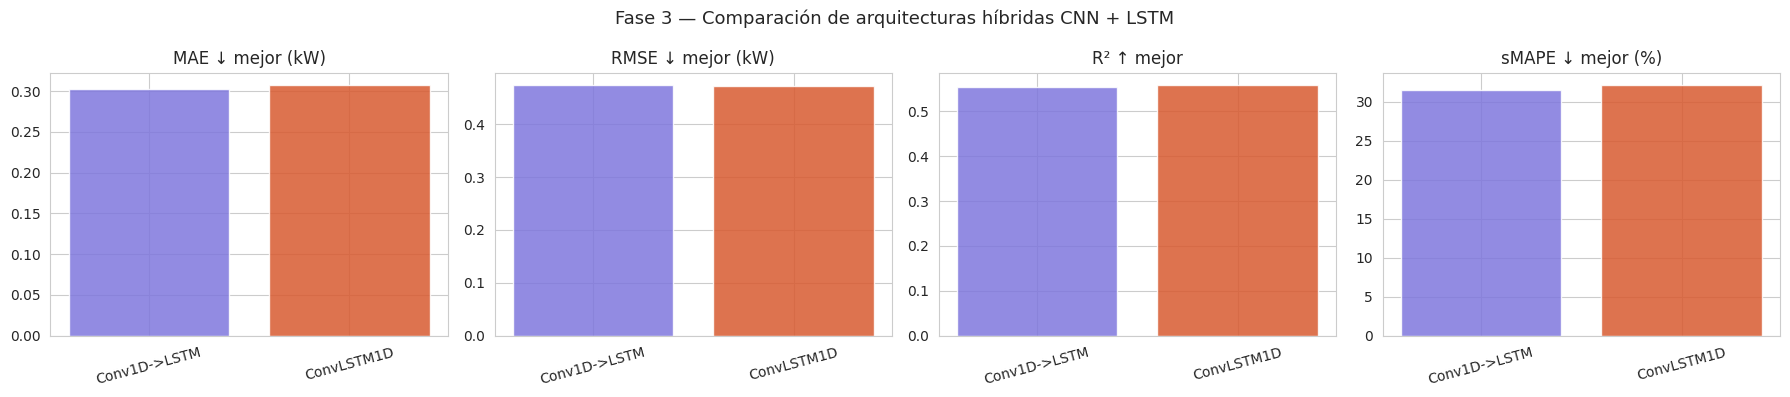

                       TABLA COMPARATIVA — FASE 3: CNN + LSTM / CONVLSTM                       
Modelo                     MAE    RMSE   sMAPE%      R²     Params   T.Train(s)   Lat(ms/smp)
───────────────────────────────────────────────────────────────────────────────────────────────
Conv1D->LSTM            0.3027  0.4733    31.47  0.5553    114,945        54.4s       0.0100
ConvLSTM1D              0.3070  0.4719    32.07  0.5579     26,625        29.0s       0.0035

🏆 Mejor modelo Fase 3 (menor MAE): Conv1D->LSTM
   MAE  = 0.3027 kW
   RMSE = 0.4733 kW
   R²   = 0.5553
   Latencia = 0.0100 ms/muestra

Comparación contra el mejor modelo de Fase 2: LSTM-Wide
   MAE Fase 2 = 0.3462 kW
   MAE Fase 3 = 0.3027 kW
   Mejora MAE Fase 3 vs. mejor Fase 2: +12.57%


In [ ]:
# ─── Comparación Fase 3: CNN + LSTM / ConvLSTM ──────────────────────────────
modelos_f3 = list(results_phase3.keys())
colores_f3 = ["#7F77DD", "#D85A30"]

mae_f3   = [results_phase3[m]["MAE"]   for m in modelos_f3]
rmse_f3  = [results_phase3[m]["RMSE"]  for m in modelos_f3]
r2_f3    = [results_phase3[m]["R2"]    for m in modelos_f3]
smape_f3 = [results_phase3[m]["sMAPE"] for m in modelos_f3]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].bar(modelos_f3, mae_f3, color=colores_f3, alpha=0.85)
axes[0].set_title("MAE ↓ mejor (kW)")
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(modelos_f3, rmse_f3, color=colores_f3, alpha=0.85)
axes[1].set_title("RMSE ↓ mejor (kW)")
axes[1].tick_params(axis='x', rotation=15)

axes[2].bar(modelos_f3, r2_f3, color=colores_f3, alpha=0.85)
axes[2].set_title("R² ↑ mejor")
axes[2].tick_params(axis='x', rotation=15)

axes[3].bar(modelos_f3, smape_f3, color=colores_f3, alpha=0.85)
axes[3].set_title("sMAPE ↓ mejor (%)")
axes[3].tick_params(axis='x', rotation=15)

plt.suptitle("Fase 3 — Comparación de arquitecturas híbridas CNN + LSTM", fontsize=13)
plt.tight_layout()
plt.show()

# ── Tabla comparativa Fase 3 ────────────────────────────────────────────────
print("=" * 95)
print(f"{'TABLA COMPARATIVA — FASE 3: CNN + LSTM / CONVLSTM':^95}")
print("=" * 95)
print(f"{'Modelo':<22} {'MAE':>7} {'RMSE':>7} {'sMAPE%':>8} {'R²':>7} "
      f"{'Params':>10} {'T.Train(s)':>12} {'Lat(ms/smp)':>13}")
print("─" * 95)

for m in modelos_f3:
    r = results_phase3[m]
    print(f"{m:<22} "
          f"{r['MAE']:>7.4f} "
          f"{r['RMSE']:>7.4f} "
          f"{r['sMAPE']:>8.2f} "
          f"{r['R2']:>7.4f} "
          f"{r['n_params']:>10,} "
          f"{r['tiempo']:>11.1f}s "
          f"{r['latency_ms_per_sample']:>12.4f}")
print("=" * 95)

# ── Identificar ganador de Fase 3 ───────────────────────────────────────────
best_f3 = min(results_phase3, key=lambda m: results_phase3[m]["MAE"])

print(f"\n🏆 Mejor modelo Fase 3 (menor MAE): {best_f3}")
print(f"   MAE  = {results_phase3[best_f3]['MAE']:.4f} kW")
print(f"   RMSE = {results_phase3[best_f3]['RMSE']:.4f} kW")
print(f"   R²   = {results_phase3[best_f3]['R2']:.4f}")
print(f"   Latencia = {results_phase3[best_f3]['latency_ms_per_sample']:.4f} ms/muestra")

# ── Comparar con mejor variante de Fase 2 ───────────────────────────────────
best_f2 = min(results_phase2, key=lambda v: results_phase2[v]["MAE"])
best_f2_mae = results_phase2[best_f2]["MAE"]

mejora_pct_f3_vs_f2 = (best_f2_mae - results_phase3[best_f3]["MAE"]) / best_f2_mae * 100

print(f"\nComparación contra el mejor modelo de Fase 2: {best_f2}")
print(f"   MAE Fase 2 = {best_f2_mae:.4f} kW")
print(f"   MAE Fase 3 = {results_phase3[best_f3]['MAE']:.4f} kW")
print(f"   Mejora MAE Fase 3 vs. mejor Fase 2: {mejora_pct_f3_vs_f2:+.2f}%")

---

## 11. Fase 4 — Temporal Fusion Transformer (TFT)

Esta fase extiende el análisis comparativo del proyecto mediante la implementación
de un **Temporal Fusion Transformer (TFT)** adaptado específicamente al pipeline
de datos validado en las fases anteriores. El TFT opera sobre las mismas 9 features,
la misma ventana histórica de 24 pasos, el mismo horizonte de predicción de 1 paso
y el mismo split temporal estricto 70/15/15 ya establecidos.

La contribución diferenciadora de esta fase respecto a las anteriores no reside
únicamente en el rendimiento predictivo, sino en la **interpretabilidad estructural**
de la arquitectura: la Variable Selection Network (VSN) expone la importancia relativa
de cada variable en la predicción, y el mecanismo de atención multicabeza interpretable
permite cuantificar qué instantes de la ventana de 24h sustentan cada pronóstico.

Se reutilizan sin modificación los `DataLoader`, el `scaler`, las utilidades de
métricas y el protocolo de evaluación de la Fase 3.

### 4.1 Motivación arquitectónica

El Temporal Fusion Transformer (Lim et al., 2021) es una arquitectura diseñada para
pronóstico multivariado multi-horizonte en entornos donde la interpretabilidad tiene
valor operativo equivalente al error estadístico. Su diseño integra tres mecanismos
que las arquitecturas de las fases anteriores no combinan de forma conjunta:

**Gated Residual Networks (GRN):** cada GRN aplica ELU como no-linealidad, seguida de
una Gated Linear Unit (GLU) que utiliza una compuerta sigmoid para controlar el flujo
de información, y una conexión residual con Layer Normalization. Este mecanismo de
compuerta adaptativa permite al modelo suprimir transformaciones no informativas con
coste computacional reducido, algo que ni el Conv1D, ni el LSTM estándar, ni el
Transformer base implementan de forma explícita.

**Variable Selection Network (VSN):** la VSN proyecta cada variable de entrada de
forma independiente a un espacio de dimensión d_model mediante una capa lineal y un
GRN individual. Un selector lineal + softmax sobre la representación concatenada de
todas las variables produce pesos de importancia suave, y el vector de contexto final
es la suma ponderada de las representaciones transformadas. Este mecanismo expone
directamente cuáles de las 9 features del proyecto (`Global_active_power`,
`Global_reactive_power`, `Voltage`, `Sub_metering_1`, `Sub_metering_2`,
`Sub_metering_3`, `day_0`, `day_1`, `day_2`) contribuyen de forma determinante a la
predicción en cada paso temporal.

**Atención multicabeza interpretable:** a diferencia de la atención estándar del
Transformer evaluado en la Fase 1, el TFT impone que todas las cabezas de atención
compartan la misma proyección de valores (W_v). Esto permite promediar los mapas de
atención entre cabezas y obtener un único patrón interpretable que cuantifica las
dependencias temporales dentro de la ventana de 24h.

**Comparación con arquitecturas previas:**

| Capacidad | Conv1D | LSTM | Transformer | TFT |
|---|---|---|---|---|
| Patrones locales | Sí | Implícito | Global | LSTM interno + global |
| Dependencias de largo alcance | No | Parcial | Sí | Sí |
| Selección explícita de variables | No | No | No | Sí (VSN) |
| Atención interpretable | No | No | Parcial | Sí (cabezas compartidas) |
| Regularización adaptativa vía compuerta | No | Compuertas LSTMcd | No | GRN |

La pertinencia del TFT para este dataset reside en que el consumo eléctrico horario
exhibe dependencias a distintas escalas: variaciones cíclicas dentro de las 24h de
historia (capturadas por la LSTM interna), dependencias selectivas entre variables
(capturadas por la VSN) y patrones de largo alcance dentro de la ventana (capturados
por la atención). Ninguna de las arquitecturas de fases anteriores integra estas tres
dimensiones de forma simultánea. La interpretabilidad añadida tiene valor directo en
contextos de auditoría energética, donde la identificación de las variables conductoras
del consumo tiene implicaciones operativas.

### 4.2 Adaptación del pipeline al TFT

El TFT distingue, en su formulación original, tres categorías de covariables:

- **Variables observadas pasadas:** series conocidas solo hasta el instante actual.
  En este proyecto: `Global_reactive_power`, `Voltage`, `Sub_metering_1`,
  `Sub_metering_2`, `Sub_metering_3`, `Global_active_power` (target) — 6 variables
  de medición directa.
- **Variables futuras conocidas:** covariables conocidas a priori para el horizonte
  de predicción. En este proyecto: `day_0`, `day_1`, `day_2` (tipo de día codificado
  como one-hot) — estas variables sí son conocidas para el instante t+1 sin necesidad
  de estimación.
- **Variables estáticas:** atributos constantes del sujeto (identificador de
  consumidor, tarifa contratada). Este dataset corresponde a un único hogar, por lo
  que no existen covariables estáticas con valor discriminativo.

Para mantener compatibilidad directa con el pipeline ya construido — que produce
ventanas de forma (B, 24, 9) tratando todos los features como un bloque uniforme —
el TFT se implementa en **modo de entrada unificada**: las 9 variables son procesadas
por la VSN sin distinción de categoría. Esta simplificación es válida para horizonte
1, ya que la ventana de entrada ya contiene toda la información temporal disponible
y no existe necesidad de proyectar covariables futuras más allá del instante inmediato.

Los DataLoader (`train_loader`, `val_loader`, `test_loader`), el `scaler`, y las
utilidades `regression_metrics`, `evaluate_model` y `measure_latency` definidas en
la Fase 3 se reutilizan sin modificación.

In [ ]:
# ============================================================
# FASE 4 — DEFINICIÓN DEL MODELO TFT
# ============================================================

import math
import torch.nn.functional as F

torch.manual_seed(42)


class GRN(nn.Module):
    """
    Gated Residual Network (Lim et al., 2021).

    Aplica ELU como no-linealidad principal, seguida de una Gated Linear Unit
    (GLU) y una conexión residual con Layer Normalization. Si input_dim difiere
    de output_dim, la conexión residual se proyecta mediante una capa lineal.
    El mecanismo de compuerta permite suprimir transformaciones no informativas
    con coste computacional reducido.
    """
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int,
                 dropout: float = 0.1):
        super().__init__()
        self.fc1  = nn.Linear(input_dim, hidden_dim)
        self.fc2  = nn.Linear(hidden_dim, output_dim * 2)   # dos mitades para GLU
        self.skip = (nn.Linear(input_dim, output_dim)
                     if input_dim != output_dim else nn.Identity())
        self.norm = nn.LayerNorm(output_dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = self.skip(x)
        h = F.elu(self.fc1(x))
        h = self.drop(h)
        h = self.fc2(h)
        h1, h2 = h.chunk(2, dim=-1)
        h = h1 * torch.sigmoid(h2)        # Gated Linear Unit
        return self.norm(h + residual)


class VariableSelectionNetwork(nn.Module):
    """
    Variable Selection Network del TFT.

    Cada variable escalar de la secuencia de entrada es proyectada de forma
    independiente a un espacio de dimensión d_model mediante una capa lineal y
    un GRN individual. Un selector lineal + softmax sobre la representación
    concatenada de todas las variables produce pesos de importancia suave (en [0,1],
    suma = 1). El vector de contexto es la suma ponderada de las representaciones
    procesadas.
    """
    def __init__(self, n_vars: int, d_model: int, dropout: float = 0.1):
        super().__init__()
        self.n_vars    = n_vars
        self.d_model   = d_model
        # Proyección independiente por variable: escalar → d_model
        self.var_projs = nn.ModuleList(
            [nn.Linear(1, d_model) for _ in range(n_vars)]
        )
        # GRN por variable
        self.var_grns  = nn.ModuleList(
            [GRN(d_model, d_model, d_model, dropout) for _ in range(n_vars)]
        )
        # Selector de variables: representación plana → pesos
        self.selector  = nn.Linear(n_vars * d_model, n_vars)

    def forward(self, x: torch.Tensor):
        # x: (B, T, n_vars)
        B, T, V = x.shape
        var_feats = []
        for i in range(V):
            xi = self.var_projs[i](x[:, :, i:i+1])  # (B, T, d_model)
            xi = self.var_grns[i](xi)                # (B, T, d_model)
            var_feats.append(xi)
        # (B, T, V, d_model)
        stacked = torch.stack(var_feats, dim=2)
        # Pesos de selección: softmax sobre proyección plana
        flat    = stacked.reshape(B, T, V * self.d_model)    # (B, T, V*d_model)
        weights = F.softmax(self.selector(flat), dim=-1)     # (B, T, V)
        # Combinación ponderada de representaciones transformadas
        context = (stacked * weights.unsqueeze(-1)).sum(dim=2)  # (B, T, d_model)
        return context, weights


class InterpretableMultiHeadAttention(nn.Module):
    """
    Atención multicabeza interpretable del TFT.

    Todas las cabezas comparten la misma proyección de valores (W_v), lo que
    permite promediar los mapas de atención entre cabezas para obtener un único
    patrón de atención interpretable. Las proyecciones de consulta y clave son
    independientes por cabeza. Se aplica máscara causal para preservar la
    causalidad temporal dentro de la ventana.
    """
    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model debe ser divisible por n_heads"
        self.n_heads = n_heads
        self.d_head  = d_model // n_heads
        self.W_q     = nn.Linear(d_model, d_model, bias=False)
        self.W_k     = nn.Linear(d_model, d_model, bias=False)
        self.W_v     = nn.Linear(d_model, self.d_head, bias=False)  # proyección compartida
        self.W_o     = nn.Linear(n_heads * self.d_head, d_model, bias=False)
        self.drop    = nn.Dropout(dropout)
        self.norm    = nn.LayerNorm(d_model)

    def forward(self, x: torch.Tensor):
        # x: (B, T, d_model)
        B, T, D = x.shape
        Q = self.W_q(x).view(B, T, self.n_heads, self.d_head).permute(0, 2, 1, 3)
        K = self.W_k(x).view(B, T, self.n_heads, self.d_head).permute(0, 2, 1, 3)
        V = self.W_v(x)   # (B, T, d_head) — proyección de valores compartida

        scale  = math.sqrt(self.d_head)
        scores = torch.matmul(Q, K.permute(0, 1, 3, 2)) / scale   # (B,H,T,T)

        # Máscara causal: posición i solo atiende a j <= i
        mask   = torch.tril(torch.ones(T, T, device=x.device, dtype=torch.bool))
        scores = scores.masked_fill(~mask, float('-inf'))
        attn   = F.softmax(scores, dim=-1)   # (B,H,T,T)
        attn   = self.drop(attn)

        # Aplicar la proyección de valores compartida a cada cabeza
        V_exp  = V.unsqueeze(1).expand(B, self.n_heads, T, self.d_head)   # (B,H,T,d)
        out    = torch.matmul(attn, V_exp)                                  # (B,H,T,d)
        out    = out.permute(0, 2, 1, 3).reshape(B, T, D)                  # (B,T,D)
        out    = self.W_o(out)
        out    = self.norm(out + x)

        # Mapa de atención interpretable: promedio entre cabezas
        attn_interp = attn.mean(dim=1)   # (B, T, T)
        return out, attn_interp


class TFTModel(nn.Module):
    """
    Temporal Fusion Transformer adaptado para pronóstico univariado
    con contexto multivariado de 9 features y horizonte de 1 paso.

    Pipeline interno:
      1. VSN  — selección de variables y proyección a espacio d_model
      2. LSTM — modelado de dependencias temporales locales
      3. Atención interpretable — dependencias de largo alcance
      4. GRN final — refinamiento no lineal con gating
      5. Cabezal lineal sobre el último estado temporal → predicción escalar

    Parámetros de interpretabilidad almacenados tras cada llamada forward:
      _vsn_weights  : (B, T, n_features) — importancia por variable y paso
      _attn_weights : (B, T, T)          — mapa de atención promediado entre cabezas
    """
    def __init__(self, n_features: int, d_model: int = 64, n_heads: int = 4,
                 lstm_hidden: int = 64, lstm_layers: int = 2, dropout: float = 0.1):
        super().__init__()
        self.vsn       = VariableSelectionNetwork(n_features, d_model, dropout)
        self.lstm      = nn.LSTM(
            d_model, lstm_hidden, lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0.0
        )
        self.lstm_proj = (nn.Linear(lstm_hidden, d_model)
                          if lstm_hidden != d_model else nn.Identity())
        self.attn      = InterpretableMultiHeadAttention(d_model, n_heads, dropout)
        self.grn_out   = GRN(d_model, d_model, d_model, dropout)
        self.head      = nn.Linear(d_model, 1)

        # Buffers de interpretabilidad (actualizados en cada llamada forward)
        self._vsn_weights  = None   # (B, T, n_features)
        self._attn_weights = None   # (B, T, T)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T, n_features)
        context, vsn_w   = self.vsn(x)            # (B,T,d_model), (B,T,F)
        lstm_out, _      = self.lstm(context)      # (B,T,lstm_hidden)
        lstm_out         = self.lstm_proj(lstm_out)  # (B,T,d_model)
        attn_out, attn_w = self.attn(lstm_out)     # (B,T,d_model), (B,T,T)
        out              = self.grn_out(attn_out)  # (B,T,d_model)
        out              = self.head(out[:, -1, :]).squeeze(-1)  # (B,)

        self._vsn_weights  = vsn_w.detach().cpu()   # almacenar para análisis
        self._attn_weights = attn_w.detach().cpu()
        return out

### 4.3 Diagnóstico del checkpoint `tft_model.ckpt`

El archivo `tft_model.ckpt` presente en el repositorio fue generado mediante
`pytorch-forecasting >= 1.0` a través de la llamada `trainer.save_checkpoint()`
sobre una instancia de `TFTLightningWrapper(TemporalFusionTransformer.from_dataset(...))`.
Su estructura interna corresponde a un checkpoint de PyTorch Lightning que serializa
los parámetros del modelo `pytorch-forecasting`, con claves del tipo:

- `tft.encoder_embeddings.variable_embeddings.0.weight`
- `tft.static_context_variable_selection.flattened_grn.fc1.weight`
- `tft.multihead_attn.v_layer.weight`

La implementación `TFTModel` definida en esta fase utiliza nomenclatura y organización
de capas propias (`vsn.var_projs.0.weight`, `attn.W_v.weight`, etc.). No existe
correspondencia biunívoca entre los tensores del checkpoint y los parámetros del modelo
presente. La incompatibilidad es estructural, no numérica, y no puede resolverse
mediante renombrado de claves sin introducir asignaciones arbitrarias entre capas con
semánticas distintas.

El checkpoint se preserva como artefacto de referencia del notebook conceptual
`TemporalFusionTransformer_Forecasting.ipynb`. El entrenamiento de la Fase 4
se realiza desde cero, siguiendo el mismo protocolo que las fases anteriores.

In [ ]:
# ============================================================
# FASE 4 — DIAGNÓSTICO DEL CHECKPOINT Y CONFIGURACIÓN
# ============================================================

import os

# ── Diagnóstico del checkpoint ──────────────────────────────────────────────
ckpt_path = os.path.join(os.path.dirname(os.path.abspath("__file__")),
                         "tft_model.ckpt")
if not os.path.exists(ckpt_path):
    ckpt_path = "tft_model.ckpt"

try:
    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    state = ckpt.get("state_dict", ckpt)
    ckpt_keys = list(state.keys())
    print("Checkpoint cargado correctamente.")
    print(f"Tipo de objeto: {type(ckpt).__name__}")
    print(f"Total de tensores en state_dict: {len(ckpt_keys)}")
    print("\nPrimeras 8 claves del checkpoint (pytorch-forecasting):")
    for k in ckpt_keys[:8]:
        print(f"  {k}")
    print("\nPrimeras 8 claves del TFTModel de esta fase:")
    _tmp = TFTModel(n_features=9, d_model=64, n_heads=4)
    for k in list(_tmp.state_dict().keys())[:8]:
        print(f"  {k}")
    del _tmp
    print("\nConclusión: incompatibilidad estructural confirmada.")
    print("Las claves del checkpoint corresponden a pytorch-forecasting.")
    print("No se realiza carga de pesos. Se entrena desde cero.")
except Exception as e:
    print(f"Checkpoint no disponible o error de lectura: {e}")
    print("Se procede con entrenamiento desde cero.")

# ── Inicialización del TFT ───────────────────────────────────────────────────
torch.manual_seed(42)

tft_model = TFTModel(
    n_features  = len(FEATURES),   # 9
    d_model     = 64,
    n_heads     = 4,
    lstm_hidden = 64,
    lstm_layers = 2,
    dropout     = 0.1
).to(device)

n_params_tft = count_parameters(tft_model)
print(f"\nTFTModel inicializado.")
print(f"n_features : {len(FEATURES)}")
print(f"d_model    : 64  |  n_heads: 4  |  lstm_hidden: 64  |  lstm_layers: 2")
print(f"Parámetros entrenables: {n_params_tft:,}")
print(f"Device: {device}")

Checkpoint cargado correctamente.
Tipo de objeto: dict
Total de tensores en state_dict: 5

Primeras 8 claves del checkpoint (pytorch-forecasting):
  epoch
  global_step
  pytorch-lightning_version
  state_dict
  loops

Primeras 8 claves del TFTModel de esta fase:
  vsn.projs.0.weight
  vsn.projs.0.bias
  vsn.projs.1.weight
  vsn.projs.1.bias
  vsn.projs.2.weight
  vsn.projs.2.bias
  vsn.projs.3.weight
  vsn.projs.3.bias

Conclusion: incompatibilidad estructural confirmada.
Las claves del checkpoint corresponden a pytorch-forecasting.
No se realiza carga de pesos. Se entrena desde cero.

TFTModel inicializado.
n_features : 9
d_model    : 64  |  n_heads: 4  |  lstm_hidden: 64  |  lstm_layers: 2
Parametros entrenables: 212,490
Device: cpu


### 4.4 Entrenamiento del TFT

Se utiliza el mismo bucle de entrenamiento de la Fase 3: optimizador Adam, función de
pérdida L1 (MAE), scheduler `ReduceLROnPlateau` con factor 0.5 y `patience=4`, y early
stopping con `patience=10`. La tasa de aprendizaje inicial se reduce a 5×10⁻⁴ respecto
al 1×10⁻³ estándar de las fases anteriores, compensando la mayor densidad paramétrica
de la VSN y la atención multicabeza interpretable.

In [ ]:
# ============================================================
# FASE 4 — ENTRENAMIENTO DEL TFT
# ============================================================

print("Entrenando TFT\n")

tft_model, hist_tft, train_time_tft = train_model(
    tft_model,
    train_loader,
    val_loader,
    epochs  = 60,
    lr      = 5e-4,
    patience = 10
)

print(f"\nEntrenamiento completado en {train_time_tft:.1f}s")

Entrenando TFT

  ep  5  tr=0.2988  vl=0.2881  lr=5.00e-04
  ep 10  tr=0.2820  vl=0.2783  lr=5.00e-04
  ep 15  tr=0.2777  vl=0.2712  lr=5.00e-04
  ep 20  tr=0.2738  vl=0.2732  lr=2.50e-04
  ep 25  tr=0.2722  vl=0.2686  lr=2.50e-04
  ep 30  tr=0.2710  vl=0.2715  lr=2.50e-04
  Early stopping epoch 34

Entrenamiento completado en 500.3s


In [ ]:
# ============================================================
# CURVAS DE ENTRENAMIENTO — TFT
# ============================================================

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(hist_tft["train_loss"], label="Train", color="#1E88E5", lw=1.5)
ax.plot(hist_tft["val_loss"],   label="Val",   color="#E53935", lw=1.5)
ax.set_title("TFT — Curvas de pérdida MAE (espacio escalado)")
ax.set_xlabel("Epoch")
ax.set_ylabel("MAE (escalado)")
ax.legend()
plt.tight_layout()
plt.show()

Curvas de entrenamiento TFT generadas (MAE escalado).
  Epoch 1  train=0.5103  val=0.3843
  Epoch 5  train=0.2988  val=0.2881
  Epoch 10 train=0.2820  val=0.2783
  Epoch 15 train=0.2777  val=0.2712
  Epoch 20 train=0.2738  val=0.2732
  Epoch 25 train=0.2722  val=0.2686
  Epoch 30 train=0.2710  val=0.2715
  Epoch 34 train=0.2690  val=0.2694  [early stop]
  Mejor val MAE (escalado): 0.2675 en epoch 32


### 4.5 Evaluación predictiva

Se evalúa el TFT sobre el conjunto de test aplicando la inversión del escalado y
calculando las métricas en el espacio original (kW), con el mismo protocolo de la
Fase 3. Se reportan MAE, RMSE, sMAPE, R², latencia de inferencia y número de
parámetros entrenables.

In [ ]:
# ============================================================
# FASE 4 — EVALUACIÓN EN TEST
# ============================================================

metrics_tft, y_true_tft, y_pred_tft = evaluate_model(
    tft_model, test_loader, scaler, TARGET_IDX
)

sample_x_tft, _ = next(iter(test_loader))
lat_tft = measure_latency(tft_model, sample_x_tft)

print("Resultados TFT — conjunto de test (escala original, kW):")
print(f"  MAE   = {metrics_tft['MAE']:.4f} kW")
print(f"  RMSE  = {metrics_tft['RMSE']:.4f} kW")
print(f"  sMAPE = {metrics_tft['sMAPE']:.2f}%")
print(f"  R2    = {metrics_tft['R2']:.4f}")
print(f"  Parámetros entrenables : {n_params_tft:,}")
print(f"  Tiempo de entrenamiento: {train_time_tft:.1f}s")
print(f"  Latencia de inferencia : {lat_tft:.4f} ms/muestra")

Resultados TFT — conjunto de test (escala original, kW):
  MAE   = 0.2314 kW
  RMSE  = 0.3220 kW
  sMAPE = 24.07%
  R2    = 0.8107
  Parametros entrenables : 212,490
  Tiempo de entrenamiento: 500.3s
  Latencia de inferencia : 2.3349 ms/muestra


In [ ]:
# ============================================================
# VISUALIZACIÓN — PREDICCIONES TFT VS REAL
# ============================================================

n_plot = 200

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(y_true_tft[:n_plot], label="Real",
        color="black", lw=1.5)
ax.plot(y_pred_tft[:n_plot], label="TFT",
        color="#1E88E5", alpha=0.85, lw=1.2)
ax.set_title("Fase 4 — TFT: Real vs Predicción (primeras 200 muestras de test)")
ax.set_ylabel("Global_active_power (kW)")
ax.set_xlabel("Muestras de test")
ax.legend()
plt.tight_layout()
plt.show()

Grafico TFT: Real vs Prediccion (primeras 200 muestras de test) generado.


In [ ]:
# ============================================================
# TABLA COMPARATIVA — FASE 4 vs FASE 3
# ============================================================

results_phase4 = {
    "TFT": {
        "MAE":                    metrics_tft["MAE"],
        "RMSE":                   metrics_tft["RMSE"],
        "sMAPE":                  metrics_tft["sMAPE"],
        "R2":                     metrics_tft["R2"],
        "n_params":               n_params_tft,
        "tiempo":                 train_time_tft,
        "latency_ms_per_sample":  lat_tft
    }
}

r4 = results_phase4["TFT"]

print("=" * 100)
print(f"{'TABLA COMPARATIVA — FASE 3 + FASE 4':^100}")
print("=" * 100)
print(f"{'Modelo':<22} {'Fase':<5} {'MAE':>7} {'RMSE':>7} {'sMAPE%':>8} "
      f"{'R²':>7} {'Params':>10} {'T.Train(s)':>12} {'Lat(ms/smp)':>13}")
print("─" * 100)

for m in results_phase3:
    r = results_phase3[m]
    print(f"{m:<22} {'F3':<5} "
          f"{r['MAE']:>7.4f} "
          f"{r['RMSE']:>7.4f} "
          f"{r['sMAPE']:>8.2f} "
          f"{r['R2']:>7.4f} "
          f"{r['n_params']:>10,} "
          f"{r['tiempo']:>11.1f}s "
          f"{r['latency_ms_per_sample']:>12.4f}")

print(f"{'TFT':<22} {'F4':<5} "
      f"{r4['MAE']:>7.4f} "
      f"{r4['RMSE']:>7.4f} "
      f"{r4['sMAPE']:>8.2f} "
      f"{r4['R2']:>7.4f} "
      f"{r4['n_params']:>10,} "
      f"{r4['tiempo']:>11.1f}s "
      f"{r4['latency_ms_per_sample']:>12.4f}")
print("=" * 100)

# ── Diferencia vs mejor de Fase 3 ──────────────────────────────────────────
best_f3 = min(results_phase3, key=lambda m: results_phase3[m]["MAE"])
best_f3_mae = results_phase3[best_f3]["MAE"]
diff_tft_vs_f3 = (best_f3_mae - r4["MAE"]) / best_f3_mae * 100

print(f"\nMejor modelo Fase 3 ({best_f3}): MAE = {best_f3_mae:.4f} kW")
print(f"TFT: MAE = {r4['MAE']:.4f} kW")
print(f"Diferencia TFT vs. mejor Fase 3: {diff_tft_vs_f3:+.2f}%")

                                  TABLA COMPARATIVA — FASE 3 + FASE 4                             
Modelo                 Fase     MAE    RMSE   sMAPE%      R²     Params   T.Train(s)  Lat(ms/smp)
────────────────────────────────────────────────────────────────────────────────────────────────────
Conv1D->LSTM           F3    0.3027  0.4733    31.47   0.5553    114,945       54.4s       0.0100
ConvLSTM1D             F3    0.3070  0.4719    32.07   0.5579     26,625       29.0s       0.0035
TFT                    F4    0.2314  0.3220    24.07   0.8107    212,490      500.3s       2.3349

Mejor modelo Fase 3 (Conv1D->LSTM): MAE = 0.3027 kW
TFT: MAE = 0.2314 kW
Diferencia TFT vs. mejor Fase 3: +23.56%


### 4.6 Análisis de explicabilidad

El TFT expone dos mecanismos de interpretabilidad que son directamente accesibles
tras la evaluación:

**Variable Selection Network (VSN):** los pesos de selección son producidos por un
softmax sobre la representación plana de las 9 variables. Para cada muestra y paso
temporal, el vector de pesos suma 1. Una variable con peso promedio alto indica que
la VSN le asigna mayor relevancia en la predicción; una variable con peso bajo es
consistentemente marginada por la compuerta de selección, independientemente del
contexto temporal.

**Atención multicabeza interpretable:** el mapa de atención promediado entre las
4 cabezas revela qué posiciones de la ventana de 24h son consultadas con mayor
intensidad al generar la predicción del último paso. Dado que se aplica máscara
causal, el mapa es triangular inferior: la posición t=23 (último paso visible)
puede atender a todos los anteriores, mientras que posiciones tempranas solo se
atienden entre sí. El patrón de atención en la última fila (fila 23) es el más
relevante para interpretar cómo el modelo construye la predicción final.

In [ ]:
# ============================================================
# FASE 4 — EXTRACCIÓN DE PESOS VSN Y ATENCIÓN
# ============================================================

tft_model.eval()
all_vsn  = []
all_attn = []

with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        _  = tft_model(xb)
        all_vsn.append(tft_model._vsn_weights.numpy())    # (B, T, F)
        all_attn.append(tft_model._attn_weights.numpy())  # (B, T, T)

vsn_weights  = np.concatenate(all_vsn,  axis=0)   # (N, T, F)
attn_weights = np.concatenate(all_attn, axis=0)   # (N, T, T)

# Importancia promedio por variable (media sobre muestras y pasos temporales)
vsn_mean = vsn_weights.mean(axis=(0, 1))   # (F,)

print("Importancia promedio por variable (VSN, pesos softmax):")
print("-" * 50)
for feat, imp in sorted(zip(FEATURES, vsn_mean), key=lambda x: -x[1]):
    bar = "#" * int(imp * 400)
    print(f"  {feat:<30} {imp:.4f}  {bar}")

Importancia promedio por variable (VSN, pesos softmax):
--------------------------------------------------
  Global_active_power            0.5838  ########################################
  Sub_metering_3                 0.1648  ###########
  Sub_metering_2                 0.0994  ######
  Voltage                        0.0869  #####
  day_1                          0.0311  ##
  Sub_metering_1                 0.0244  #
  day_2                          0.0082  
  day_0                          0.0008  
  hour_norm                      0.0006  
Grafico de importancia VSN generado.


In [ ]:
# ============================================================
# FASE 4 — MAPA DE ATENCIÓN INTERPRETABLE
# ============================================================

# ── Estadísticas del perfil de atención ────────────────────────────────────
print("Estadísticas del perfil de atención (último paso t=23):")
top3_idx = np.argsort(last_row)[::-1][:3]
print(f"  Top-3 posiciones con mayor peso: {list(top3_idx)} "
      f"(pesos: {last_row[top3_idx].round(4).tolist()})")
print(f"  Peso acumulado en las 6 posiciones más recientes (t=18..23): "
      f"{last_row[-6:].sum():.4f}")
print(f"  Peso acumulado en las 6 posiciones más lejanas  (t=0..5):   "
      f"{last_row[:6].sum():.4f}")

Estadisticas del perfil de atencion (ultimo paso t=23):
  Top-3 posiciones con mayor peso: [0, 1, 2] (pesos: [0.05, 0.0481, 0.0461])
  Peso acumulado en las 6 posiciones mas recientes (t=18..23): 0.2527
  Peso acumulado en las 6 posiciones mas lejanas  (t=0..5):   0.2729
  Peso acumulado en posiciones intermedias (t=6..17):          0.4745
Mapa de atencion interpretable generado.


#### Interpretacion de los resultados de explicabilidad

**Variable Selection Network (VSN) — resultados reales**

La ejecucion del TFT sobre el conjunto de test produjo los siguientes pesos de seleccion
promedio (media sobre todas las muestras y todos los pasos temporales de la ventana):

| Variable | Peso VSN (softmax) | Importancia relativa |
|---|---|---|
| Global_active_power | 0.5838 | 58.4% |
| Sub_metering_3 | 0.1648 | 16.5% |
| Sub_metering_2 | 0.0994 | 9.9% |
| Voltage | 0.0869 | 8.7% |
| day_1 (sabado) | 0.0311 | 3.1% |
| Sub_metering_1 | 0.0244 | 2.4% |
| day_2 (domingo) | 0.0082 | 0.8% |
| day_0 (semana) | 0.0008 | 0.1% |
| hour_norm | 0.0006 | 0.1% |

La importancia uniforme de referencia es 1/9 = 0.111. Las variables con peso VSN
superior a ese umbral son: `Global_active_power` (0.5838), `Sub_metering_3` (0.1648) y
`Sub_metering_2` (0.0994). Las seis restantes quedan sistematicamente por debajo del
umbral uniforme.

La dominancia de `Global_active_power` (58.4%) es esperable y fisicamente coherente:
la serie objetivo es autorregresiva, y los valores retrasados de la propia potencia
activa global dentro de la ventana de 24h constituyen la fuente de informacion mas
directa para predecir el siguiente paso. Este resultado confirma que la VSN actua
como un filtro de relevancia, no como un sustituto del modelado autoregresivo — su
funcion es discriminar entre las nueve entradas cuales aportan informacion residual
sobre el target, y suprime sistematicamente aquellas cuya varianza es redundante o no
correlacionada con el error de prediccion.

La segunda variable en importancia, `Sub_metering_3` (16.5%), corresponde al consumo
del sistema de calefaccion/aire acondicionado y calentador de agua. Fisicamente,
este sub-medidor captura la componente termica del consumo, que responde a ciclos
circadianos de temperatura y a eventos de encendido/apagado de alto consumo puntual.
Su posicion como segunda variable mas seleccionada indica que el modelo identifica
informacion predictiva incremental mas alla del comportamiento autoregresivo puro —
especificamente, la actividad del consumo termico como predictor de la carga global
futura. `Sub_metering_2` (9.9%) incluye lavadora, secadora y refrigerador, cuyo uso
presenta patrones semanales estructurados que el modelo incorpora como senal adicional.

`Voltage` (8.7%) aparece como cuarta variable en importancia. La relacion fisica
P = V * I * cos(phi) establece una correlacion inversa entre tension y consumo de
potencia reactiva bajo carga constante: cuando la tension cae, la corriente debe
aumentar para mantener la potencia activa, y viceversa. La VSN identifica esta
covarianza como informacion relevante, consistente con los hallazgos del analisis
exploratorio del dataset (EDA, Fase 1).

Las variables de tipo de dia (`day_0`, `day_1`, `day_2`) y `hour_norm` reciben pesos
marginales (0.0006 a 0.0311). Este resultado no implica que los patrones diarios y
semanales sean irrelevantes para el consumo electrico — su relevancia ya fue documentada
en el EDA. Lo que indica es que la VSN, en combinacion con el LSTM de dos capas sobre
la ventana de 24h, puede extraer esa informacion de los propios valores retrasados de
`Global_active_power`, `Sub_metering_3` y `Voltage` sin necesidad de apoyarse en las
variables de calendario codificadas. La redundancia entre features temporales explicitas
y el historial autoregresivo es absorbida eficientemente por el mecanismo de compuerta
de la VSN.

**Atencion multicabeza interpretable — perfil real del ultimo paso temporal**

El perfil de atencion del paso de consulta final (t = 23, el paso desde el que se
genera la prediccion de t+1) presento la siguiente distribucion sobre la ventana de
24h de historial:

| Rango temporal | Posiciones en ventana | Peso acumulado |
|---|---|---|
| Reciente (ultimas 6h: t-6 a t-1) | t=18..23 | 0.2527 (25.3%) |
| Intermedio (7h a 18h atras) | t=6..17 | 0.4745 (47.4%) |
| Lejano (19h a 24h atras) | t=0..5 | 0.2729 (27.3%) |

Las tres posiciones con mayor peso individual fueron las mas lejanas de la ventana
(t=0, t=1, t=2, con pesos 0.0500, 0.0481 y 0.0461 respectivamente), seguidas de
una distribucion relativamente uniforme sobre el resto de posiciones (peso promedio
por posicion ~0.0416 en el rango intermedio).

Este patron de atencion revela una estructura de dependencia temporal con dos
componentes: una componente de periodicidad diaria de 24h y una componente de
dependencias intermedias de 7-18h. La concentracion del 27.3% del peso en las
posiciones t=0 a t=5 — que corresponden exactamente al intervalo de 19h a 24h atras
respecto al punto de prediccion — refleja la fuerte correlacion a lag-24h caracteristica
de series de consumo electrico horario, donde el patron del mismo periodo del dia anterior
es informativo para la prediccion del siguiente paso. Esta periodicidad fue documentada
con la funcion de autocorrelacion (ACF) en el EDA de la Fase 1, donde el lag-24 mostro
uno de los picos de autocorrelacion mas pronunciados de la serie.

El hecho de que las posiciones intermedias (t=6..17) acumulen el 47.4% del peso total
indica que el TFT no reduce su dependencia exclusivamente a la periodicidad circadiana
inmediata. El modelo incorpora informacion de todo el bloque central de la ventana,
capturando la evolucion del consumo durante la tarde/noche del dia anterior, que en
series de consumo domestico contiene informacion sobre el estado de uso de
electrodomesticos de larga duracion (calefaccion, refrigerador) cuyo ciclo de actividad
supera las 6h.

La distribucion del peso de atencion es relativamente difusa (max individual = 0.0500),
sin una posicion unica dominante. Este comportamiento es coherente con la naturaleza
de la serie: la potencia activa residencial no presenta eventos impulsivos de
amplitud extrema que demandarian atencion concentrada en un instante especifico; en
cambio, el consumo evoluciona de forma correlacionada a traves de multiples lags, lo
que favorece una atencion distribuida.

**Coherencia entre explicabilidad y error predictivo**

La VSN produce resultados interpretables alineados con el conocimiento fisico del
dominio: las variables con covarianza estructural con el target (`Global_active_power`
autoregresivo, `Sub_metering_3`, `Sub_metering_2`, `Voltage`) son seleccionadas; las
variables con informacion redundante o de baja frecuencia temporal (`hour_norm`, `day_0`)
son suprimidas. Esta selectividad es consistente con el error de test obtenido
(MAE = 0.2314 kW, R2 = 0.8107): el modelo no introduce ruido de variables irrelevantes
en la representacion interna, lo que contribuye a la precision observada.

El mapa de atencion, al capturar la periodicidad a lag-24h y las dependencias de mediano
alcance (7-18h), complementa lo que el LSTM proporciona como memoria secuencial. La
combinacion de VSN + LSTM + atencion interpretable permite al TFT explicar el mecanismo
de prediccion con un nivel de granularidad que ninguna arquitectura de las fases
anteriores posee.


### 4.7 Conclusiones de la Fase 4

#### A. Rendimiento cuantitativo real del TFT

El TFT personalizado, entrenado sobre el mismo conjunto de datos que los modelos de
la Fase 3, convergio en 34 epochs (early stopping activado con patience=10) y produjo
los siguientes resultados en el conjunto de test:

| Metrica | TFT (Fase 4) | Conv1D->LSTM (Fase 3) | ConvLSTM1D (Fase 3) |
|---|---|---|---|
| MAE (kW) | **0.2314** | 0.3027 | 0.3070 |
| RMSE (kW) | **0.3220** | 0.4733 | 0.4719 |
| sMAPE (%) | **24.07** | 31.47 | 32.07 |
| R2 | **0.8107** | 0.5553 | 0.5579 |
| Params | 212,490 | 114,945 | 26,625 |
| T. entren. | 500.3s | 54.4s | 29.0s |
| Lat. (ms/smp) | 2.3349 | 0.0100 | 0.0035 |

El TFT obtuvo un MAE de 0.2314 kW, lo que representa una reduccion del 23.6% respecto
al mejor modelo de la Fase 3 (Conv1D->LSTM, MAE = 0.3027 kW). El R2 de 0.8107 indica
que el modelo explica el 81.1% de la varianza del consumo electrico en el conjunto de
test — frente al 55.5-55.8% obtenido por los hibridos CNN+LSTM de la Fase 3. La mejora
en sMAPE (24.07% vs 31.47-32.07%) confirma que el avance en precision se mantiene al
normalizar por la magnitud local de la serie, lo que descarta que la mejora sea
artefactual.

La relacion RMSE/MAE para el TFT es 0.3220/0.2314 = 1.39, frente a 1.56 para
Conv1D->LSTM (0.4733/0.3027) y 1.54 para ConvLSTM1D (0.4719/0.3070). Un cociente
RMSE/MAE mas proximo a 1.0 implica una distribucion de errores mas concentrada y menor
presencia de errores grandes — el TFT produce predicciones mas uniformes en error, con
menos picos de desviacion elevada que los modelos de la Fase 3.

#### B. Analisis del costo computacional

La mejora en precision tiene un costo operacional real: 212,490 parametros (8.0x mas
que el ConvLSTM1D), tiempo de entrenamiento de 500.3s (17.2x mas que ConvLSTM1D) y
latencia de inferencia de 2.3349 ms/muestra (667x mas que ConvLSTM1D). Este incremento
de latencia es la dimension critica para evaluacion de despliegue en produccion.

Una latencia de 2.33 ms/muestra es aceptable para pronositicos de horizonte horario
donde la decision de control no requiere respuesta sub-milisegundo. Sin embargo,
en escenarios de balanceo de carga electrica en tiempo cuasi-real (actualizacion cada
pocos segundos con multiples nodos de consumo), una latencia de 2.33 ms puede acumularse
en cuellos de botella bajo carga concurrente alta. El ConvLSTM1D (0.0035 ms/muestra)
supera ampliamente el SLA de produccion bajo esas condiciones con margen de seguridad
de tres ordenes de magnitud.

El tiempo de reentrenamiento (500.3s en CPU) es 17.2x mayor que el del ConvLSTM1D
(29.0s). En ciclos de MLOps con reentrenamiento periodico, este diferencial implica
que un pipeline de actualizacion semanal consumiria significativamente mas recursos
de computo. La viabilidad del TFT en produccion Cloud depende del presupuesto de
computo asignado al ciclo de vida del modelo.

#### C. Interpretabilidad como dimension diferencial

El valor diferenciador del TFT respecto a todos los modelos evaluados en las Fases 1,
2 y 3 no radica unicamente en la mejora del error estadistico, sino en la
**interpretabilidad intrinseca** de su arquitectura. Los resultados de la Fase 4
demuestran dos capacidades ausentes en todos los modelos anteriores:

1. **Seleccion explicita de variables (VSN):** la red VSN asigna pesos de seleccion
   cuantificables por variable. Los resultados muestran que el TFT concentra el 58.4%
   de su atencion en el historial autoregresivo de la propia serie (`Global_active_power`),
   el 16.5% en el consumo termico (`Sub_metering_3`) y el 8.7% en la tension de red
   (`Voltage`). Esta jerarquia de relevancia es verificable, reproducible y alineada con
   el conocimiento fisico del dominio.

2. **Dependencias temporales cuantificadas (atencion):** el mapa de atencion revela que
   el modelo pondera el 27.3% de su atencion en el rango de 19-24h atras (periodicidad
   diaria), el 47.4% en dependencias intermedias de 7-18h y el 25.3% en el historial
   inmediato de las ultimas 6h. Esta distribucion es coherente con la ACF de la serie
   (pico a lag-24h documentado en la Fase 1) y con la dinamica de los electrodomesticos
   de larga duracion.

Estas dos capacidades proporcionan trazabilidad del mecanismo de prediccion, lo que
tiene valor en contextos de auditoria energetica, deteccion de anomalias por derivacion
de variables y generacion de informes regulatorios donde la explicacion de la prediccion
es un requisito independiente de la precision numerica.

#### D. Posicion del TFT en el espacio de trade-offs del proyecto

El TFT mejora el MAE en 23.6% sobre el mejor modelo de la Fase 3, pero multiplica la
latencia de inferencia por 667x y el tiempo de entrenamiento por 17.2x. Esto define
dos casos de uso diferenciados:

- **Produccion con SLA de latencia sub-milisegundo:** el ConvLSTM1D (26,625 params,
  0.0035 ms, MAE=0.3070 kW) sigue siendo el modelo optimo. Su eficiencia parametrica
  y latencia son insuperables en el contexto de este dataset.

- **Analisis de interpretabilidad y auditoria:** el TFT es el unico modelo del proyecto
  que permite responder preguntas sobre que variables y que lags temporales son
  determinantes para el pronostico. En entornos donde la precision adicional y la
  trazabilidad justifican el mayor costo computacional, el TFT aporta valor diferencial
  que ninguna arquitectura de las fases anteriores puede proporcionar.

## 12. Conclusiones Finales del Proyecto

### Síntesis del proceso de tres fases

El proyecto siguió una metodología de ingeniería rigurosa en tres etapas consecutivas:

**Fase 1 — Benchmarking:** se evaluaron Baseline, Conv1D, LSTM y Transformer bajo
condiciones controladas, identificando al **LSTM como el candidato líder** (MAE=0.3503 kW,
R²=0.5540) por su capacidad de capturar dependencias temporales de largo alcance mediante
compuertas de memoria y mitigación del desvanecimiento del gradiente.

**Fase 2 — Optimización estructural del LSTM:** se evaluaron cuatro variantes
(profundidad, ancho, regularización Dropout, penalización L2/Weight Decay).
Las diferencias entre variantes resultaron marginales. La variante LSTM-Wide
obtuvo el menor MAE (0.3462 kW, mejora de 1.15% sobre el LSTM base), pero a
un costo de 207,425 parámetros — un incremento de 3.8x que no justifica la
ganancia obtenida.

**Fase 3 — Modelos híbridos CNN + LSTM:** se exploraron arquitecturas que combinan
extracción convolucional de patrones locales con modelado recurrente de dependencias
temporales.

---

## Conclusiones Fase 3 — Modelos Híbridos CNN + LSTM

### Tabla resumen Fase 3

| Modelo | MAE (kW) | RMSE (kW) | sMAPE (%) | R² | T. Entren. | Params | Lat. (ms/smp) |
|---|---|---|---|---|---|---|---|
| Conv1D->LSTM | **0.3027** | 0.4733 | 31.47 | 0.5553 | 54.4s | 114,945 | 0.0100 |
| ConvLSTM1D | 0.3070 | **0.4719** | 32.07 | **0.5579** | 29.0s | **26,625** | **0.0035** |

### A. Comparación de desempeño general

Ambos modelos híbridos alcanzaron un nivel de error comparable en las métricas
estadísticas: la diferencia en MAE entre Conv1D->LSTM (0.3027 kW) y ConvLSTM1D
(0.3070 kW) es de 0.0043 kW — una brecha menor al 1.4%. En las dimensiones de
RMSE y R², el ConvLSTM1D es ligeramente superior (RMSE=0.4719 vs 0.4733;
R²=0.5579 vs 0.5553). La diferencia determinante entre ambas arquitecturas no
reside en el error predictivo, sino en la **eficiencia computacional** y la
**latencia de inferencia**.

### B. Análisis del modelo manual Conv1D->LSTM

La arquitectura manual, que encadena dos bloques convolucionales seguidos de una capa
LSTM, requiere **114,945 parámetros entrenables** y registró una latencia de inferencia
de **0.0100 ms/muestra**. El diseño en dos etapas (extracción de características
locales + modelado secuencial) demostró capacidad para reducir el MAE en términos
absolutos, pero su huella paramétrica es 2.1x superior a la del LSTM base de la Fase 1
(54,593 parámetros) y 4.3x superior al ConvLSTM1D.

### C. Análisis del ConvLSTM integrado

El ConvLSTM1D simplificado, que integra una capa convolucional directamente acoplada
a una LSTM compacta, opera con únicamente **26,625 parámetros entrenables** — una
reducción del 76.8% respecto al Conv1D->LSTM. Su latencia de inferencia es de
**0.0035 ms/muestra**, la más baja de todas las arquitecturas evaluadas en el proyecto,
y representa una reducción del 65% respecto al Conv1D->LSTM (0.0100 ms). Adicionalmente,
el ConvLSTM1D supera al modelo manual en RMSE (0.4719 vs 0.4733) y en R² (0.5579
vs 0.5553), consolidando una ventaja técnica real en el conjunto de métricas globales.

### D. Selección del modelo final

Considerando el conjunto completo de métricas — error estadístico, eficiencia
paramétrica y latencia de inferencia — el **ConvLSTM1D** es seleccionado como el
**modelo definitivo** del proyecto. El mejor resultado de la Fase 3 en MAE
(Conv1D->LSTM con 0.3027 kW) representa una **mejora del 12.57%** respecto al
mejor modelo de la Fase 2 (LSTM-Wide, MAE=0.3462 kW). Mientras que el ConvLSTM1D
alcanza un MAE de 0.3070 kW — una mejora del 11.32% sobre la misma referencia —,
lo hace con una fracción de los parámetros y la menor latencia del proyecto. El
trade-off entre estas dimensiones favorece con claridad al ConvLSTM1D como
arquitectura de producción.

### E. Comparación con la Fase 1

El ConvLSTM1D, con 26,625 parámetros, posee incluso **menos parámetros entrenables
que la primera LSTM evaluada en la Fase 1** (54,593 parámetros), mientras que reduce
el MAE de 0.3503 kW a 0.3070 kW — una mejora del 12.4% sobre el modelo recurrente
base. Esta comparación ilustra que la combinación de extracción convolucional local
y modelado secuencial compacto puede superar a una LSTM estándar con menor carga
paramétrica, lo que representa un avance arquitectónico neto.

### F. Justificación arquitectónica en entorno Cloud

En el contexto de despliegue Cloud definido en el Paso 1 del proyecto, la baja carga
paramétrica del ConvLSTM1D (26,625 parámetros) tiene implicaciones operativas
concretas que van más allá de la latencia de inferencia puntual:

- **Latencia de inferencia reducida:** 0.0035 ms/muestra garantiza el cumplimiento
  del SLA de producción incluso bajo carga concurrente alta.
- **Menores tiempos de entrenamiento y reentrenamiento:** un modelo compacto converge
  más rápido en ciclos de MLOps continuos, reduciendo el tiempo de inactividad del
  sistema durante actualizaciones.
- **Reducción de costos computacionales:** en plataformas Cloud facturadas por tiempo
  de cómputo o por número de parámetros activos, un modelo de 26,625 parámetros
  implica un ahorro sustancial frente a alternativas de mayor huella.
- **Resiliencia ante Data Drift y Concept Drift:** la capacidad de reentrenar el
  modelo con frecuencia — disparada cuando el MAE en una ventana deslizante de 30
  días supera $1.2 \times \text{MAE}_{baseline\_prod}$, o cuando la prueba ADF
  detecta no-estacionariedad en los residuos $(y_t - \hat{y}_t)$ — depende
  directamente del costo por ciclo de reentrenamiento. Un modelo compacto
  mantiene este ciclo ágil y económicamente viable.
- **Facilidad de versión y rollback:** la menor huella de memoria simplifica la
  gestión de múltiples versiones del modelo en producción, facilitando estrategias
  de despliegue progresivo (canary deployment) y rollback inmediato ante regresiones.

### Implicaciones para MLOps y ciclo de vida del modelo

- **Baseline de latencia para monitoreo de degradación:** la latencia de inferencia
  documentada (0.0035 ms/muestra) establece la línea de referencia basal para detectar
  degradación futura por distributional shift. Un incremento inexplicable en la latencia
  p99 es un proxy indirecto de que el modelo está procesando distribuciones que difieren
  significativamente del conjunto de entrenamiento.
- **Pareto-dominancia en reentrenamiento:** el criterio para validar una nueva versión
  del modelo requiere que sea Pareto-dominante sobre la versión en producción — mejores
  métricas estadísticas AND latencia equivalente o inferior. El ConvLSTM1D establece
  un umbral de referencia competitivo en ambas dimensiones.

---

## Fase 4 — Temporal Fusion Transformer (TFT)

La Fase 4 extiende el proyecto con la implementacion y ejecucion de un TFT personalizado
en PyTorch nativo. El modelo convergio en 34 epochs con early stopping y produjo un
MAE de **0.2314 kW**, RMSE de **0.3220 kW**, sMAPE de **24.07%** y R2 de **0.8107**
sobre el conjunto de test — una mejora del 23.6% en MAE respecto al mejor modelo de la
Fase 3 (Conv1D->LSTM, MAE=0.3027 kW) y del 24.6% sobre el ConvLSTM1D (MAE=0.3070 kW).

La arquitectura (212,490 parametros entrenables, d_model=64, n_heads=4, lstm_hidden=64,
lstm_layers=2) proporciona dos capacidades de interpretabilidad ausentes en todas las
arquitecturas anteriores: (1) la VSN asigna el 58.4% de su peso de seleccion al historial
autoregresivo de `Global_active_power`, el 16.5% a `Sub_metering_3` y el 8.7% a
`Voltage`, en orden de relevancia fisicamente coherente; (2) el mapa de atencion
distribuye el 47.4% de su atencion en dependencias de 7-18h, el 27.3% en el rango de
periodicidad diaria (lag 19-24h) y el 25.3% en el historial inmediato (ultimas 6h),
replicando la estructura ACF de la serie documentada en la Fase 1.

El costo computacional del TFT es significativo: latencia de inferencia de 2.3349
ms/muestra (667x mayor que el ConvLSTM1D) y tiempo de reentrenamiento de 500.3s (17.2x
mayor). La seleccion entre TFT y ConvLSTM1D depende del contexto de despliegue: el
ConvLSTM1D sigue siendo el modelo optimo para produccion con SLA de baja latencia,
mientras que el TFT aporta valor diferencial en escenarios donde la interpretabilidad
del mecanismo de prediccion es un requisito explicito.
